In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']

import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
from scipy.stats import boxcox
from scipy.special import inv_boxcox

import jax.numpy as jnp
import jax.random as random
rng = random.PRNGKey(2025)
from tqdm import tqdm

from utils import find_recipe_in_batch, normalize_recipe_by_calories, plot_recipe

import seaborn as sns
gt_color = np.array((59, 124, 243))/256
pr_color = np.array((117, 251, 76))/256

In [3]:
with open('data/burgers_step8.pkl', 'rb') as f:
    gt_recipes, ingr_names, calorie_database = pickle.load(f)
calorie_database = calorie_database.copy()
calorie_database_corrections = {
    "breadcrumb": 3.95,
    "mustard": 0.66,
    "chipotle chili": 0.40,
    "cajun seasoning": 2.50,
    "chili flake": 3.18,
    "chicken seasoning": 2.00,
    "italian seasoning": 2.65,
    "steak seasoning": 2.50,
    "liquid smoke": 0.00,
}
for ingr, corrected_cal_per_g in calorie_database_corrections.items():
    if ingr in calorie_database:
        calorie_database[ingr] = corrected_cal_per_g


n_recipes = len(gt_recipes)
n_ingr = len(ingr_names)
indices, repeat_counts = np.loadtxt(f"params/repeat_counts_vegetarian_rng_42.txt").T

# 1. Determine main ingredient of each vegetarian recipe

## 1.1. By calories

In [ ]:
# load all vegetarian recipes
print('Number of vegetarian recipes in 1 million: ', len(indices))
dummy_recipe = find_recipe_in_batch(indices[0])

# find main ingredient of each recipe by calories
main_ingr_by_cal = []
for idx in tqdm(indices):
    recipe = find_recipe_in_batch(idx)
    ingr_calories = np.zeros_like(recipe)

    for i in range(len(ingr_names)):
        ingr_name = ingr_names[i]
        ingr_cal_per_gram = calorie_database[ingr_name]
        ingr_calories[i] = recipe[i] * ingr_cal_per_gram
    main_ingr_by_cal.append(np.argmax(ingr_calories))
main_ingr_by_cal = np.array(main_ingr_by_cal)
np.savetxt(f'params/main_ingr_by_calories_rng_42.txt', np.stack([indices, main_ingr_by_cal]), fmt="%d", delimiter=" ")
ingrs_by_cal, counts_by_cal = np.unique(main_ingr_by_cal, return_counts=True)

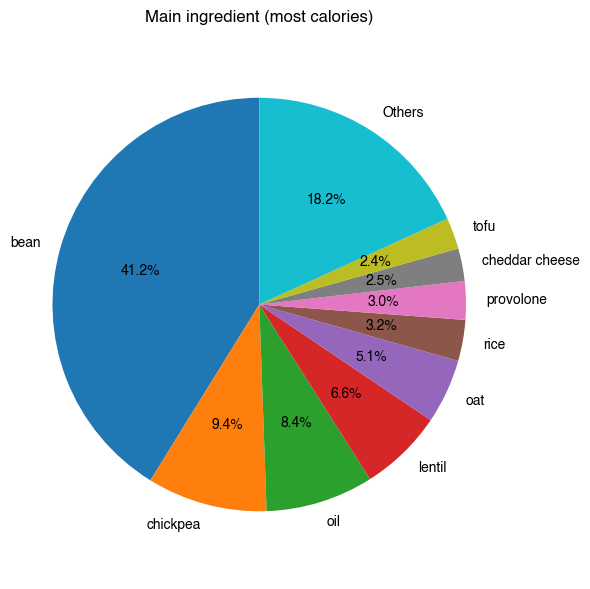

In [4]:
# Convert to arrays (in case they aren't already)
labels_arr = np.array(ingr_names[ingrs_by_cal])
counts_arr = np.array(counts_by_cal)

# 1) Sort by counts (descending)
order = np.argsort(counts_arr)[::-1]
labels_sorted = labels_arr[order]
counts_sorted = counts_arr[order]

# 2) Keep first 9, group the rest into "Others"
top_n = 9

labels_final = list(labels_sorted[:top_n])
counts_final = list(counts_sorted[:top_n])

if len(counts_sorted) > top_n:
    labels_final.append("Others")
    counts_final.append(counts_sorted[top_n:].sum())

# Plot
plt.figure(figsize=(6, 6))
plt.pie(
    counts_final,
    labels=labels_final,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Main ingredient (most calories)')
plt.axis('equal')
plt.tight_layout()
plt.show()


## 1.2. By weight

In [5]:
# find main ingredient of each recipe by weight
main_ingr_by_wgt = []
for idx in tqdm(indices):
    recipe = find_recipe_in_batch(idx)
    main_ingr_by_wgt.append(np.argmax(recipe))
main_ingr_by_wgt = np.array(main_ingr_by_wgt)
np.savetxt(f'params/main_ingr_by_weight_rng_42.txt', np.stack([indices, main_ingr_by_wgt]), fmt="%d", delimiter=" ")

100%|██████████| 162017/162017 [01:23<00:00, 1942.33it/s]


In [4]:
_, main_ingr_by_wgt = np.loadtxt(f'params/main_ingr_by_weight_rng_42.txt')
main_ingr_by_wgt = main_ingr_by_wgt.astype(int)

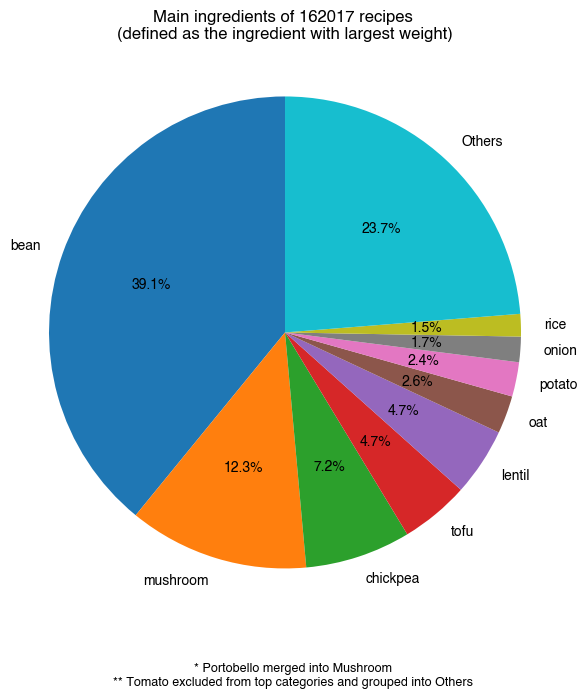

In [189]:
ingrs_by_wgt, counts_by_wgt = np.unique(main_ingr_by_wgt, return_counts=True)
labels_arr = np.array(ingr_names[ingrs_by_wgt])
counts_arr = np.array(counts_by_wgt)

# --- 1) Combine "portobello" into "mushroom" ---
mask_mushroom = labels_arr == "mushroom"
mask_portobello = labels_arr == "portobello"

if mask_portobello.any():
    if mask_mushroom.any():
        counts_arr[mask_mushroom] += counts_arr[mask_portobello].sum()
    else:
        labels_arr = np.append(labels_arr, "mushroom")
        counts_arr = np.append(counts_arr, counts_arr[mask_portobello].sum())

    keep = ~mask_portobello
    labels_arr = labels_arr[keep]
    counts_arr = counts_arr[keep]

# --- 2) Separate "tomato" so it always goes to Others ---
mask_tomato = labels_arr == "tomato"
tomato_count = counts_arr[mask_tomato].sum()

labels_arr = labels_arr[~mask_tomato]
counts_arr = counts_arr[~mask_tomato]

# --- 3) Sort by counts (descending) ---
order = np.argsort(counts_arr)[::-1]
labels_sorted = labels_arr[order]
counts_sorted = counts_arr[order]

# --- 4) Keep top 9, group rest + tomato into "Others" ---
top_n = 9

labels_final = list(labels_sorted[:top_n])
counts_final = list(counts_sorted[:top_n])

others_count = counts_sorted[top_n:].sum() + tomato_count
if others_count > 0:
    labels_final.append("Others")
    counts_final.append(others_count)

# --- 5) Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    counts_final,
    labels=labels_final,
    autopct="%1.1f%%",
    startangle=90
)
ax.axis("equal")

# --- 6) Footnotes ---
fig.text(
    0.5, -0.05,
    "* Portobello merged into Mushroom\n"
    "** Tomato excluded from top categories and grouped into Others",
    ha="center",
    va="top",
    fontsize=9
)

plt.tight_layout()
plt.title(f'Main ingredients of {len(indices)} recipes \n(defined as the ingredient with largest weight)')
plt.show()


# 2. Survey recipes

Recipes to be used in the survey:

1. Bean (re-doing the previous bean burger with a different prep method)
2. Mushroom
3. Chickpea
4. Lentil (skip tofu because it is uninteresting)
5. Oat
6. Oat + fruit

Rules:
1. Ignore all ingredients that are less than 1 g
2. Limit ingredient numbers to [5,10]

## 2.1. AI Designed Recipes

### 2.1.1. Mushroom

In [190]:
ai_recipes = {}

Index of selected recipe:  623818


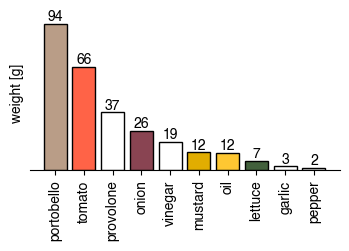

In [191]:
mshrm_idx = np.where(ingr_names=='mushroom')[0][0]
portb_idx = np.where(ingr_names=='portobello')[0][0]
mshrm_recipes_mask = main_ingr_by_wgt == mshrm_idx
portb_recipes_mask = main_ingr_by_wgt == portb_idx

mshrm_recipes_mask = np.logical_or(mshrm_recipes_mask, portb_recipes_mask)
mshrm_recipes, mshrm_recipes_repeat_counts = indices[mshrm_recipes_mask], repeat_counts[mshrm_recipes_mask]

order = np.argsort(mshrm_recipes_repeat_counts)[::-1]
for idx_max in order:
    recipe = find_recipe_in_batch(mshrm_recipes[idx_max])
    recipe[recipe<1] = 0
    recipe_n_ingr = sum(recipe>0)
    if recipe_n_ingr <= 10 and recipe_n_ingr >= 5:
        print("Index of selected recipe: ", int(mshrm_recipes[idx_max]))
        recipe = normalize_recipe_by_calories(recipe)
        plot_recipe(recipe)
        ai_recipes["mushroom"] = recipe
        break

### 2.1.2. Chickpea

Index of selected recipe:  266714


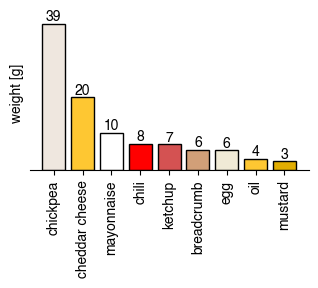

In [192]:
chickpea_idx = np.where(ingr_names=='chickpea')[0][0]
chickpea_recipes_mask = main_ingr_by_wgt == chickpea_idx
chickpea_recipes, chickpea_recipes_repeat_counts = indices[chickpea_recipes_mask], repeat_counts[chickpea_recipes_mask]

order = np.argsort(chickpea_recipes_repeat_counts)[::-1]
for idx_max in order:
    recipe = find_recipe_in_batch(chickpea_recipes[idx_max])
    recipe[recipe<1] = 0
    recipe_n_ingr = sum(recipe>0)
    if recipe_n_ingr <= 10 and recipe_n_ingr >= 5:
        print("Index of selected recipe: ", int(chickpea_recipes[idx_max]))
        recipe = normalize_recipe_by_calories(recipe)
        plot_recipe(recipe)
        ai_recipes["chickpea"] = recipe
        break

### 2.1.3. Lentil

Index of selected recipe:  857991


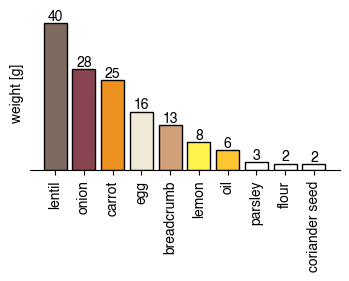

In [193]:
lentil_idx = np.where(ingr_names=='lentil')[0][0]
lentil_recipes_mask = main_ingr_by_wgt == lentil_idx
lentil_recipes, lentil_recipes_repeat_counts = indices[lentil_recipes_mask], repeat_counts[lentil_recipes_mask]

order = np.argsort(lentil_recipes_repeat_counts)[::-1]
for idx_max in order:
    recipe = find_recipe_in_batch(lentil_recipes[idx_max])
    recipe[recipe<1] = 0
    recipe_n_ingr = sum(recipe>0)
    if recipe_n_ingr <= 10 and recipe_n_ingr >= 5:
        print("Index of selected recipe: ", int(lentil_recipes[idx_max]))
        recipe = normalize_recipe_by_calories(recipe)
        plot_recipe(recipe)
        ai_recipes["lentil"] = recipe
        break

### 2.1.4. Oat

Index of selected recipe:  824691


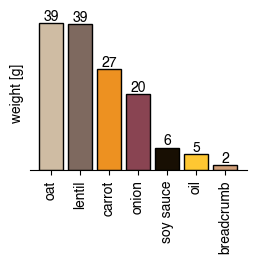

In [194]:
oat_idx = np.where(ingr_names=='oat')[0][0]
oat_recipes_mask = main_ingr_by_wgt == oat_idx
oat_recipes, oat_recipes_repeat_counts = indices[oat_recipes_mask], repeat_counts[oat_recipes_mask]

order = np.argsort(oat_recipes_repeat_counts)[::-1]
for idx_max in order:
    recipe = find_recipe_in_batch(oat_recipes[idx_max])
    recipe[recipe<1] = 0
    recipe_n_ingr = sum(recipe>0)
    if recipe_n_ingr <= 10 and recipe_n_ingr >= 5:
        print("Index of selected recipe: ", int(oat_recipes[idx_max]))
        recipe = normalize_recipe_by_calories(recipe)
        plot_recipe(recipe)
        ai_recipes['oat_savory'] = recipe
        break

### 2.1.5. Oat + Fruit

Index of selected recipe:  773152


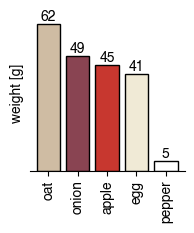

In [195]:
fruits = ['apple', 'cranberry', 'mango', 'orange', 'pineapple']
oat_fruit_recipes = []
oat_fruit_repeat_counts = []
for idx, repeat_count in zip(oat_recipes, oat_recipes_repeat_counts):
    recipe = find_recipe_in_batch(idx)
    has_fruit = False
    for fruit_name in fruits:
        idx_fruit = np.where(ingr_names == fruit_name)[0][0]
        if recipe[idx_fruit] > 0:
            has_fruit = True
    if has_fruit:
        oat_fruit_recipes.append(idx)
        oat_fruit_repeat_counts.append(repeat_count)

order = np.argsort(oat_fruit_repeat_counts)[::-1]
for idx_max in order:
    recipe = find_recipe_in_batch(oat_fruit_recipes[idx_max])
    recipe[recipe<1] = 0
    recipe_n_ingr = sum(recipe>0)
    if recipe_n_ingr <= 10 and recipe_n_ingr >= 5:
        print("Index of selected recipe: ", int(oat_fruit_recipes[idx_max]))
        recipe = normalize_recipe_by_calories(recipe)
        plot_recipe(recipe)
        ai_recipes["oat_sweet"] = recipe
        break

### 2.1.6. The bean burger redo

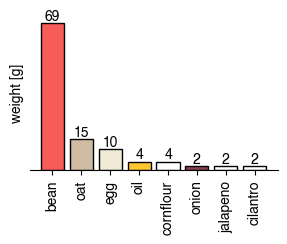

In [196]:
bean_burger_init = {'bean': 71,
                    'cilantro': 2,
                    'cornflour': 4,
                    'cumin': 0.2,
                    'egg': 10,
                    'jalapeno': 2,
                    'oat': 15,
                    'oil': 4,
                    'onion': 2,
                    'oregano': 0.05,
                    'pepper': 0.2}

recipe = np.zeros_like(gt_recipes[0])
for name, qnty in bean_burger_init.items():
    idx_ingr = np.where(ingr_names == name)[0][0]
    recipe[idx_ingr] = qnty

recipe[recipe<1] = 0
recipe = normalize_recipe_by_calories(recipe)
plot_recipe(recipe)
ai_recipes['bean'] = recipe

## 2.2. Chef designed recipes

bean
chickpea
lentil
mushroom
oat_savory
oat_sweet


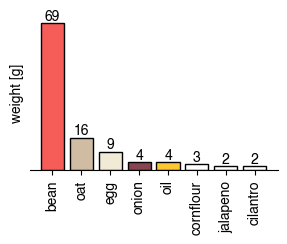

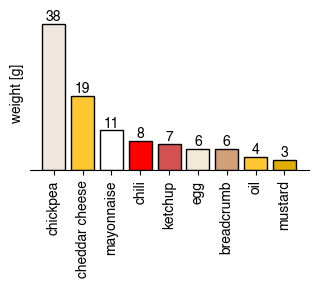

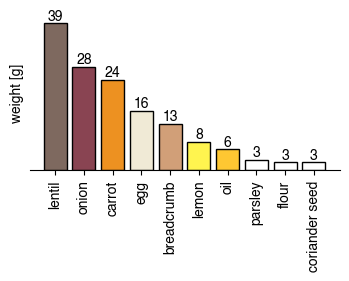

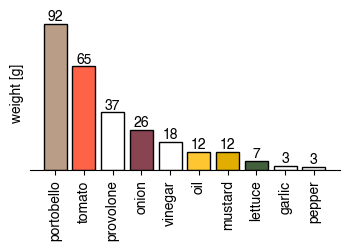

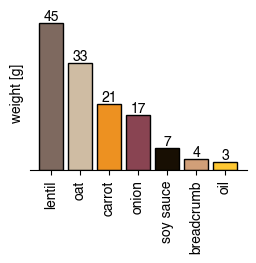

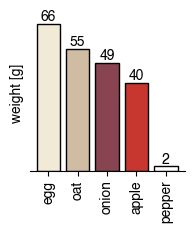

In [197]:
chef_recipes_dict = {
    'bean': {
        'bean': 72,
        'oat': 16,
        'onion': 4,
        'jalapeno': 2,
        'cilantro': 2,
        'egg': 9,
        'cornflour': 3,
        'oil': 4
    },
    'chickpea': {
        'chickpea': 55,
        'cheddar cheese': 28,
        'mayonnaise': 15,
        'chili': 11,
        'ketchup': 10,
        'breadcrumb': 8,
        'egg': 8,
        'oil': 5,
        'mustard': 4, 
    },
    'lentil': {
        'lentil': 31.7,
        'onion': 22.3,
        'carrot': 19.5,
        'egg': 12.8,
        'breadcrumb': 10,
        'lemon': 6.1,
        'oil': 4.5,
        'parsley': 2.2,
        'flour': 1.7,
        'coriander seed': 1.7,
    },
    'mushroom': {
        'portobello': 134,
        'tomato': 95,
        'provolone': 53,
        'onion': 37,
        'vinegar': 26,
        'mustard': 17,
        'oil': 17,
        'lettuce': 9,
        'garlic': 4,
        'pepper': 3,
    },
    'oat_savory': {
        'oat': 29,
        'lentil': 40,
        'carrot': 18,
        'onion': 15,
        'soy sauce': 6,
        'oil': 2,
        'breadcrumb': 3,
    },
    'oat_sweet': {
        'oat': 29.4,
        'egg': 35.4,
        'apple': 21.2,
        'onion': 26,
        'pepper': 1,
    }
}

chef_recipes = {}
for name, recipe_dict in chef_recipes_dict.items():
    print(name)
    recipe = np.zeros_like(gt_recipes[0])
    for ingr_name, qnty in recipe_dict.items():
        idx_ingr = np.where(ingr_names == ingr_name)[0][0]
        recipe[idx_ingr] = qnty
    recipe = normalize_recipe_by_calories(recipe)
    plot_recipe(recipe)
    chef_recipes[name] = recipe

## 2.3. Comparison

In [217]:
ingr_names_short = ingr_names.copy()
ingr_names_short[ingr_names_short == 'breadcrumb'] = 'brdcrmb'
ingr_names_short[ingr_names_short == 'cheddar cheese'] = 'cheddar'
ingr_names_short[ingr_names_short == 'coriander seed'] = 'coriander'
ingr_names_short[ingr_names_short == 'mayonnaise'] = 'mayo'

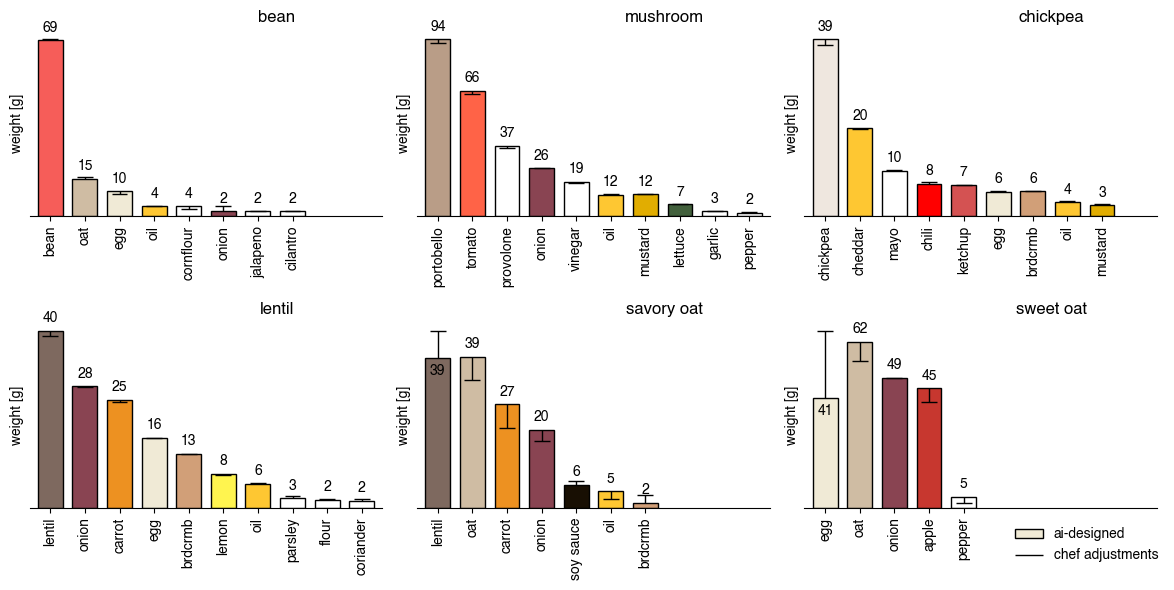

In [232]:
bar_color_dict = {
    'onion': '#894452',
    'beef': np.array([180, 30, 30])/256,
    'cheese': np.array([255, 200, 50])/256,
    'cheddar cheese': np.array([255, 200, 50])/256,
    'cheddar': np.array([255, 200, 50])/256,
    'other cheese': np.array([255, 200, 50])/256,
    'bun': np.array([210, 160, 120])/256,
    'breadcrumb': np.array([210, 160, 120])/256,
    'brdcrmb': np.array([210, 160, 120])/256,
    'tortilla': np.array([210, 160, 120])/256,
    'pickle': np.array([131, 161, 105])/256,
    'mushroom': np.array([186, 158, 136])/256,
    'portobello': np.array([186, 158, 136])/256,
    'greens': np.array([66, 96, 60])/256,
    'lettuce': np.array([66, 96, 60])/256,
    'jalopeno': np.array([66, 96, 60])/256,
    'turkey': np.array([195, 138, 138])/256,
    'pineapple': np.array([254, 234, 99])/256,
    'teriyaki sauce': np.array([126, 92, 73])/256,
    'fish': np.array([250, 128, 114])/256,
    'bean': np.array([247, 93, 89])/256,
    'corn': 'yellow',
    'oil': np.array([255, 200, 50])/256,
    'chili': 'red',
    'salsa': 'red',
    'lentil': '#7E695F',
    'carrot': '#ED9121',
    'egg': '#F0EAD6',
    'lemon': '#FFF44F',
    'oat': '#CFBCA3',
    'chickpea': '#EFE7DF',
    'ketchup': '#d45252',
    'soy sauce': '#180F03',
    'apple': '#C7372F',
    'tomato': '#FF6347',
    'mustard': '#E1AD01',
}
def plot_recipe_comparison(ai_recipe, chef_recipe, name=None, ax=None, xlim=None):
    """Plot AI weights as bars and chef adjustments as whiskers.

    xlim is the number of ingredient positions to display. Passing the same
    value for every subplot keeps the bar widths consistent across axes.
    """
    # from utils import bar_color_dict

    ai_recipe = np.asarray(ai_recipe)
    chef_recipe = np.asarray(chef_recipe)
    if ai_recipe.shape != ingr_names_short.shape or chef_recipe.shape != ingr_names_short.shape:
        raise ValueError(f'Both recipes must have shape {ingr_names_short.shape}.')

    # Retain ingredients used in either recipe and remove salt.
    mask = ((ai_recipe > 0) | (chef_recipe > 0)) & (ingr_names_short != 'salt')
    ai_masked = ai_recipe[mask]
    chef_masked = chef_recipe[mask]
    ingr_names_masked = ingr_names_short[mask]

    # As in plot_recipe, show the largest ingredients first.
    order = np.argsort(np.maximum(ai_masked, chef_masked))[::-1]
    ai_masked = ai_masked[order]
    chef_masked = chef_masked[order]
    ingr_names_masked = ingr_names_masked[order]

    colors = [bar_color_dict.get(ingr_name, 'white') for ingr_name in ingr_names_masked]
    if xlim is None:
        xlim = len(ingr_names_masked)
    if xlim < len(ingr_names_masked):
        raise ValueError('xlim cannot be smaller than the number of plotted ingredients.')

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(xlim * 0.75, 6), 4))
    else:
        fig = ax.figure

    x = np.arange(len(ingr_names_masked))
    width = 0.72
    ai_bars = ax.bar(
        x, ai_masked, width, color=colors, edgecolor='black',
        label='ai-designed',
    )

    # Draw a one-ended whisker from each AI amount to the chef amount.
    # The cap is placed only at the chef endpoint, producing a T for an
    # upward correction and an inverted T for a downward correction.
    cap_half_width = width * 0.32
    ax.vlines(
        x, ai_masked, chef_masked, colors='k', zorder=3, linewidth=1,
    )
    ax.hlines(
        chef_masked, x - cap_half_width, x + cap_half_width,
        colors='k', label='chef adjustments', zorder=3, linewidth=1,
    )
    for bar, ai_value, chef_value in zip(ai_bars, ai_masked, chef_masked):
        if ai_value <= 0:
            continue
        adjustment_is_upward = chef_value - ai_value > 2.5
        ax.annotate(
            str(int(np.ceil(ai_value))),
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, -4 if adjustment_is_upward else 4),
            textcoords='offset points',
            ha='center',
            va='top' if adjustment_is_upward else 'bottom',
        )

    ax.set(ylabel='weight [g]', title=name, yticks=[])
    ax.set_xlim(-0.6, xlim - 0.4)
    ax.set_xticks(x, ingr_names_masked, rotation=90)
    ax.set_ylabel('weight [g]')
    ax.set_title(name, y=1.0, x = 0.7, ha='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    return fig, ax


recipe_order = ['bean', 'mushroom', 'chickpea', 'lentil', 'oat_savory', 'oat_sweet']
recipe_titles = {
    'bean': 'bean',
    'mushroom': 'mushroom',
    'chickpea': 'chickpea',
    'lentil': 'lentil',
    'oat_savory': 'savory oat',
    'oat_sweet': 'sweet oat',
}

ingredient_counts = [
    np.count_nonzero(
        ((ai_recipes[name] > 0) | (chef_recipes[name] > 0))
        & (ingr_names != 'salt')
    )
    for name in recipe_order
]
max_ingredients = max(ingredient_counts)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for recipe_name, ax in zip(recipe_order, axes.flat):
    plot_recipe_comparison(
        ai_recipes[recipe_name],
        chef_recipes[recipe_name],
        name=recipe_titles[recipe_name],
        ax=ax,
        xlim=max_ingredients,
    )

# The following is necessary because otherwise matplotlib puts "chef adjustments" first in the legend
handles, labels = axes[1, 2].get_legend_handles_labels()
order = [
    labels.index('ai-designed'),
    labels.index('chef adjustments'),
]
axes[1, 2].legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    frameon=False,
    loc='center',
    bbox_to_anchor=(0.8,-0.2)
)

fig.tight_layout()
fig.savefig('figs/ai_vs_chef.pdf', bbox_inches='tight')


In [78]:
with open('data/survey_recipes_chef.pkl', 'wb') as f:
    pickle.dump(chef_recipes, f)

# 3. Environmental impacts

In [9]:
with open('data/survey_recipes_chef.pkl', 'rb') as f:
    chef_recipes = pickle.load(f)
recipe_titles = {
    'bean': 'bean',
    'mushroom': 'mushroom',
    'chickpea': 'chickpea',
    'lentil': 'lentil',
    'oat_savory': 'savory oat',
    'oat_sweet': 'sweet oat',
}

# Read the LCA database
env_data = pd.read_excel("data/environmental/environmental_data.xlsx", sheet_name="augmented w condiments")
ing_2_lca = pd.read_excel("data/environmental/environmental_data.xlsx", sheet_name="lca names to ingredient names")

ing_2_lca_dict = {} # find the lca food category name given ingredient name
for i in range(len(ing_2_lca)):
    ing_name = ing_2_lca['Recipe Database Food Categories'][i]
    lca_name = ing_2_lca['Environmental Database Food Categories'][i]
    ing_2_lca_dict[ing_name] = lca_name

env_score_dict = {}
lu_list, ghg_list, ep_list, wu_list = [], [], [], []
normalization = [20.2, 62.2, 174/1000, 43600] # directly taken from the supplement of Clark et al 2022 (Page 10)
for i in range(len(ingr_names)):
    ing_name = ingr_names[i]
    lca_name = ing_2_lca_dict[ing_name]
    search_result = env_data[env_data['Product'] == lca_name].to_numpy().squeeze()
    lu_norm, ghg_norm, ep_norm, wu_norm = search_result[2:]/normalization # land use, greenhouse gas, eutrophication potential, scarcity-weighted water use, respectively.
    env_score = 1/4*(lu_norm + ghg_norm + ep_norm + wu_norm)
    env_score = env_score/1000 # convert from -/kg to -/g
    env_score_dict[ing_name] = {
        'score': env_score,
        'lu': search_result[2]/1000, #m^2/g
        'ghg': search_result[3]/1000, #kg CO2-eq/g
        'ep': search_result[4]/1000*1000, # g PO43-eq/g  # converting to g PO43-eq
        'wu': search_result[5]/1000/1000 # kL-eq/g # converting to kL-eq
    }

with open('data/environmental/ingr_env_impact_scores.pkl', 'wb') as f:
    pickle.dump(env_score_dict, f)

In [6]:
with open(f'data/bm_recipe.npy', 'rb') as f:
    bigmac_recipe = pickle.load(f)
# need to remove 'bun'
with open('data/prev_burgers_step8.pkl', 'rb') as f:
    _, prev_ingr_names, _ = pickle.load(f)
idx_bun = np.where(prev_ingr_names=='bun')[0][0]
bigmac_recipe = np.hstack([bigmac_recipe[:idx_bun], bigmac_recipe[idx_bun+1:]])
bigmac_recipe = normalize_recipe_by_calories(bigmac_recipe)

survey_recipes = chef_recipes.copy()
survey_recipes['bigmac'] = bigmac_recipe

In [7]:
def make_representative_recipe(recipe, target_calories=350):
    """Remove condiments and rescale the remaining ingredients to target_calories."""
    representative_recipe = np.asarray(recipe, dtype=float).copy()
    if representative_recipe.shape != ingr_names.shape:
        raise ValueError(
            f'Recipe has shape {representative_recipe.shape}; expected {ingr_names.shape}.'
        )

    condiment_mask = np.array([
        str(ing_2_lca_dict[ingr_name]).strip().lower() == 'condiments'
        for ingr_name in ingr_names
    ])
    representative_recipe[condiment_mask] = 0

    calories_per_gram = np.array([
        calorie_database[ingr_name] for ingr_name in ingr_names
    ], dtype=float)
    remaining_calories = float(np.dot(representative_recipe, calories_per_gram))
    if not np.isfinite(remaining_calories) or remaining_calories <= 0:
        raise ValueError('Recipe has no positive-calorie, non-condiment ingredients.')

    representative_recipe *= target_calories / remaining_calories
    return representative_recipe


def calculate_recipe_impact(recipe):
    representative_recipe = make_representative_recipe(recipe)
    score, lu, ghg, ep, wu = 0, 0, 0, 0, 0
    for i, ingr_name in enumerate(ingr_names):
        weight = representative_recipe[i]
        ingr_score, ingr_lu, ingr_ghg, ingr_ep, ingr_wu = env_score_dict[ingr_name].values()

        score   += weight * ingr_score
        lu      += weight * ingr_lu
        ghg     += weight * ingr_ghg
        ep      += weight * ingr_ep
        wu      += weight * ingr_wu

    return {
        'score': score,
        'lu': lu,
        'ghg': ghg,
        'ep': ep,
        'wu': wu,
    }

chef_recipe_impacts = {}
for name, recipe in chef_recipes.items():
    chef_recipe_impacts[name] = calculate_recipe_impact(recipe)

bigmac_impacts = calculate_recipe_impact(survey_recipes['bigmac'])

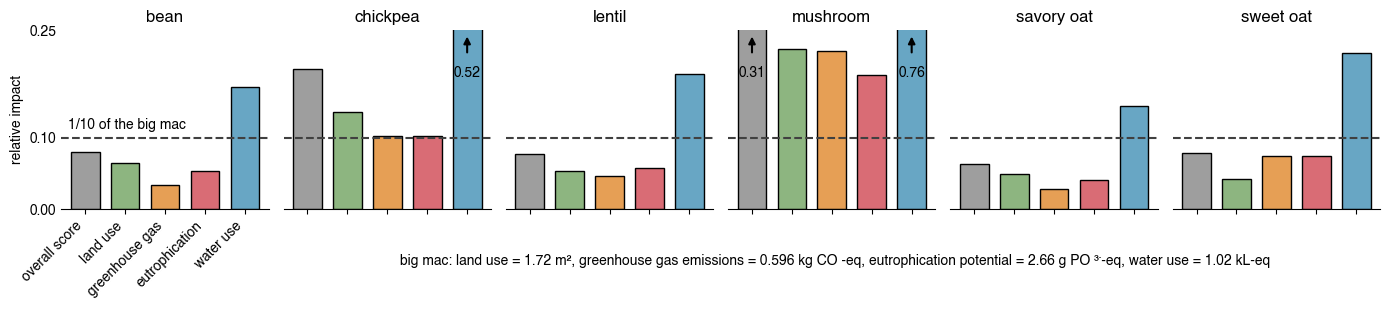

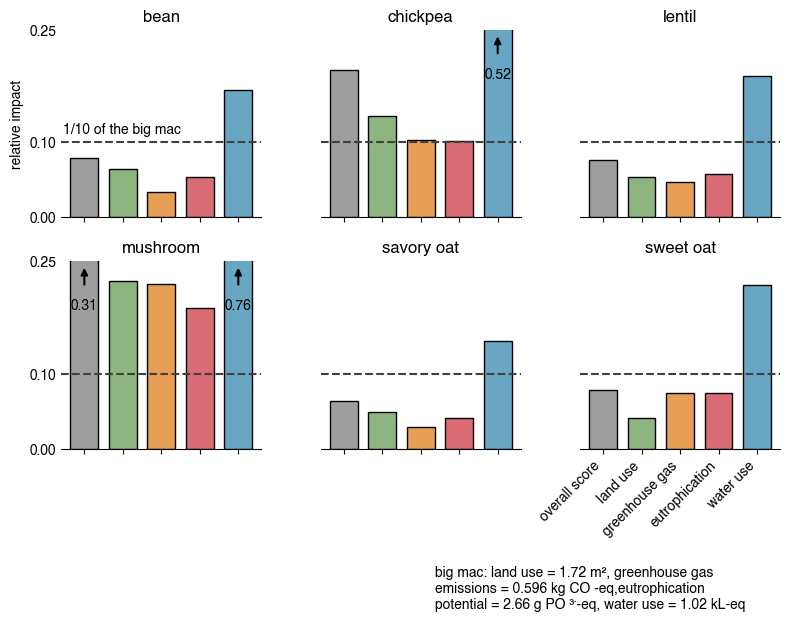

In [23]:
# Plot each impact as a fraction of the corresponding full Big Mac impact.
impact_keys = ['score', 'lu', 'ghg', 'ep', 'wu']
impact_labels = [
    'overall score',
    'land use',
    'greenhouse gas',
    'eutrophication',
    'water use',
]

# Show the six chef recipes in a single row.
chef_plot_order = ['bean', 'chickpea', 'lentil', 'mushroom', 'oat_savory', 'oat_sweet']

bigmac_values = np.array([bigmac_impacts[key] for key in impact_keys])
if np.any(bigmac_values <= 0):
    raise ValueError('All Big Mac impact values must be positive.')

chef_relative_impacts = {
    name: np.array([chef_recipe_impacts[name][key] for key in impact_keys]) / bigmac_values
    for name in chef_plot_order
}
x = np.arange(len(impact_keys))
impact_colors = ['#9e9e9e', '#8db580', '#e69f55', '#d96c75', '#68a6c4']

# def format_relative_value(value):
#     return f'{value:.2g}×'

fig, axes = plt.subplots(1, 6, figsize=(14, 3.8), sharey=True)

def label_impact_bars(ax, bars, relative_values):
    """Mark only values clipped by the y-axis ceiling."""
    for bar, relative_value in zip(bars, relative_values):
        bar_center = bar.get_x() + bar.get_width() / 2
        if relative_value > 0.25:
            ax.annotate(
                '', xy=(bar_center, 0.245), xytext=(bar_center, 0.215),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5),
                clip_on=False,
            )
            ax.text(
                bar_center, 0.2, f'{relative_value:.2g}',
                ha='center', va='top', fontweight='bold',
            )


# Chef recipes, expressed as fractions of the category-specific Big Mac impacts.
for ax, recipe_name in zip(axes, chef_plot_order):
    relative_values = chef_relative_impacts[recipe_name]
    bars = ax.bar(
        x, relative_values, edgecolor='black', width=0.72, color=impact_colors,
    )
    ax.set_title(recipe_titles.get(recipe_name, recipe_name))
    label_impact_bars(ax, bars, relative_values)
    ax.axhline(
        0.1, color='0.25', linestyle='--', linewidth=1.5, zorder=1,
    )

for axis_index, ax in enumerate(axes):
    ax.set_xticks(x)
    if axis_index == 0:
        ax.set_xticklabels(impact_labels, rotation=45, ha='right')
    else:
        ax.tick_params(axis='x', labelbottom=False)
    ax.set_ylim(0, 0.25)
    ax.set_yticks([0, 0.1, 0.25])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('relative impact')
axes[0].annotate(
    '1/10 of the big mac',
    xy=(0.6, 0.1), xycoords=('axes fraction', 'data'),
    xytext=(0, 4), textcoords='offset points',
    ha='right', va='bottom',
    bbox=dict(facecolor='white', edgecolor='none', pad=1),
)

bigmac_tenth = 0.1 * bigmac_values
reference_label = (
    'big mac: '
    f'land use = {bigmac_tenth[1]:.3g} m², '
    f'greenhouse gas emissions = {bigmac_tenth[2]:.3g} kg CO₂-eq, '
    f'eutrophication potential = {bigmac_tenth[3]:.3g} g PO₄³⁻-eq, '
    f'water use = {bigmac_tenth[4]:.3g} kL-eq'
)
fig.text(
    0.6, 0.3, reference_label, ha='center', va='center',
)
# fig.suptitle('Environmental impacts', fontweight='bold')
fig.tight_layout(rect=[0, 0.16, 1, 1])

fig.savefig('figs/env_impacts_vs_bigmac.pdf', bbox_inches='tight')

# Also save a two-row version, with three recipes per row.
fig_2row, axes_2row = plt.subplots(
    2, 3, figsize=(8, 6.5), sharey=True,
)
axes_2row_flat = axes_2row.ravel()

for ax, recipe_name in zip(axes_2row_flat, chef_plot_order):
    relative_values = chef_relative_impacts[recipe_name]
    bars = ax.bar(
        x, relative_values, edgecolor='black', width=0.72, color=impact_colors,
    )
    ax.set_title(recipe_titles.get(recipe_name, recipe_name))
    label_impact_bars(ax, bars, relative_values)
    ax.axhline(
        0.1, color='0.25', linestyle='--', linewidth=1.5, zorder=1,
    )

for axis_index, ax in enumerate(axes_2row_flat):
    ax.set_xticks(x)
    if axis_index == 5:
        ax.set_xticklabels(impact_labels, rotation=45, ha='right')
    else:
        ax.tick_params(axis='x', labelbottom=False)
    ax.set_ylim(0, 0.25)
    ax.set_yticks([0, 0.1, 0.25])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

axes_2row[0, 0].set_ylabel('relative impact')
axes_2row[0, 0].annotate(
    '1/10 of the big mac',
    xy=(0.6, 0.1), xycoords=('axes fraction', 'data'),
    xytext=(0, 4), textcoords='offset points',
    ha='right', va='bottom',
    bbox=dict(facecolor='white', edgecolor='none', pad=1),
)

reference_label_2row = (
    'big mac: '
    f'land use = {bigmac_tenth[1]:.3g} m², '
    f'greenhouse gas\nemissions = {bigmac_tenth[2]:.3g} kg CO₂-eq,'
    f'eutrophication\npotential = {bigmac_tenth[3]:.3g} g PO₄³⁻-eq, '
    f'water use = {bigmac_tenth[4]:.3g} kL-eq'
)
fig_2row.text(
    0.55, 0.05, reference_label_2row, ha='left', va='bottom',
)
fig_2row.tight_layout(rect=[0, 0.14, 1, 1])
fig_2row.savefig('figs/env_impacts_vs_bigmac_2rows.pdf', bbox_inches='tight')


# 4. Nutrition & Sustainability facts labels

In [179]:
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea
import ipywidgets as widgets
from IPython.display import display

with open('data/ingredient_nutrient_info.pkl', 'rb') as f:
    nutrient_names, _, ingredient_nutrients = pickle.load(f)
nutrient_names = np.asarray(nutrient_names)
ingredient_nutrients = np.asarray(ingredient_nutrients, dtype=float)

# The nutrient file comes from the previous 146-ingredient database. Align it
# with the current database by removing the obsolete bun row.
if ingredient_nutrients.shape[0] == len(prev_ingr_names):
    keep_nutrients = np.asarray(prev_ingr_names) != 'bun'
    aligned_names = np.asarray(prev_ingr_names)[keep_nutrients]
    ingredient_nutrients = ingredient_nutrients[keep_nutrients]
    if not np.array_equal(aligned_names, np.asarray(ingr_names)):
        raise ValueError('Nutrient rows do not align with ingr_names after removing bun.')
elif ingredient_nutrients.shape[0] != len(ingr_names):
    raise ValueError('Unexpected number of rows in ingredient_nutrient_info.pkl.')

nutrient_index = {name: i for i, name in enumerate(nutrient_names)}

def recipe_nutrient_amount(recipe, nutrient_name, unit='g'):
    amount_g = float(np.dot(recipe, ingredient_nutrients[:, nutrient_index[nutrient_name]]))
    if unit == 'mg':
        return amount_g * 1_000
    if unit == 'mcg':
        return amount_g * 1_000_000
    return amount_g

def percent_dv(amount, daily_value):
    return f'{round(100 * amount / daily_value):.0f}%'

def nutrition_facts(recipe):
    recipe = normalize_recipe_by_calories(recipe, target_calories=350)
    fat = recipe_nutrient_amount(recipe, 'fat')
    saturated = recipe_nutrient_amount(recipe, ' saturated')
    sodium = recipe_nutrient_amount(recipe, 'sodium', 'mg')
    carbohydrate = recipe_nutrient_amount(recipe, 'carbohydrate')
    fiber = recipe_nutrient_amount(recipe, 'fiber')
    sugars = recipe_nutrient_amount(recipe, 'total sugars')
    protein = recipe_nutrient_amount(recipe, 'protein')
    vitamin_d = recipe_nutrient_amount(recipe, 'vitamin d', 'mcg')
    calcium = recipe_nutrient_amount(recipe, 'calcium', 'mg')
    iron = recipe_nutrient_amount(recipe, 'iron', 'mg')
    potassium = recipe_nutrient_amount(recipe, 'potassium', 'mg')

    return {
        'calories': 350,
        'rows': [
            ('Total Fat', f'{fat:.1f} g', percent_dv(fat, 78), False, True),
            ('Saturated Fat', f'{saturated:.1f} g', percent_dv(saturated, 20), True, False),
            ('Trans Fat', '—', '', True, False),
            ('Cholesterol', '—', '', False, True),
            ('Sodium', f'{sodium:.0f} mg', percent_dv(sodium, 2300), False, True),
            ('Total Carbohydrate', f'{carbohydrate:.1f} g', percent_dv(carbohydrate, 275), False, True),
            ('Dietary Fiber', f'{fiber:.1f} g', percent_dv(fiber, 28), True, False),
            ('Total Sugars', f'{sugars:.1f} g', '', True, False),
            ('Includes Added Sugars', '—', '', True, False),
            ('Protein', f'{protein:.1f} g', percent_dv(protein, 50), False, True),
        ],
        'micronutrients': [
            ('Vitamin D', f'{vitamin_d:.1f} mcg', percent_dv(vitamin_d, 20)),
            ('Calcium', f'{calcium:.0f} mg', percent_dv(calcium, 1300)),
            ('Iron', f'{iron:.1f} mg', percent_dv(iron, 18)),
            ('Potassium', f'{potassium:.0f} mg', percent_dv(potassium, 4700)),
        ],
    }

facts_title_font = FontProperties(
    fname='/System/Library/Fonts/Supplemental/Arial Bold.ttf', size=26
)

def initialize_facts_axis(ax, bottom=0.02):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(Rectangle((0.03, bottom), 0.94, 0.98 - bottom, fill=False, linewidth=2.2, color='black'))

def draw_rule(ax, y, linewidth=0.7):
    # A butt cap ends exactly at x1/x2 instead of projecting past them by
    # half the linewidth, so rules of different thickness align visually.
    ax.plot(
        [0.055, 0.945], [y, y], color='black', linewidth=linewidth,
        solid_capstyle='butt',
    )

def draw_header(ax, title):
    ax.text(0.06, 0.945, title, fontproperties=facts_title_font, va='top')
    draw_rule(ax, 0.9)
    ax.text(0.06, 0.875, 'Serving size 1 burger', fontweight='bold', va='top')
    # ax.text(0.94, 0.875, '1 burger', fontweight='bold', ha='right', va='top')
    draw_rule(ax, 0.83, linewidth=7)
    ax.text(0.06, 0.8, 'Calories', fontsize=17, fontweight='black', va='top')
    ax.text(0.94, 0.8, '350', fontsize=22, fontweight='black', ha='right', va='top')
    draw_rule(ax, 0.745, linewidth=4)

def draw_nutrition_label(ax, facts):
    initialize_facts_axis(ax, bottom=0.095)
    draw_header(ax, 'Nutrition Facts')
    ax.text(0.94, 0.73, '% Daily Value*', fontweight='bold', ha='right', va='top')
    y = 0.7
    row_step = 0.037
    for label, amount, dv, indent, bold in facts['rows']:
        x = 0.09 if indent else 0.06
        ax.text(x, y, f'{label}  {amount}', fontweight='bold' if bold else 'normal', va='top')
        ax.text(0.94, y, dv, fontweight='bold', ha='right', va='top')
        draw_rule(ax, y - 0.027, linewidth=4 if label == 'Protein' else 0.7)
        y -= row_step

    y -= 0.020
    for label, amount, dv in facts['micronutrients']:
        ax.text(0.06, y, f'{label}  {amount}', va='top')
        ax.text(0.94, y, dv, ha='right', va='top')
        draw_rule(ax, y - 0.027)
        y -= 0.037

    ax.text(
        0.06, 0.11,
        '* The % Daily Value tells you how much a nutrient in a serving contributes\n'
        '  to a daily diet. 2,000 calories a day is used for general nutrition advice.',
        fontsize=7.5, va='bottom',
    )

def format_sustainability_number(key, value, decimal_places=2):
    """Format with a fixed number of decimal places and no scientific notation."""
    value = float(value)
    if not np.isfinite(value):
        return '—'
    return f'{value:.{decimal_places}f}'

def sustainability_unit(key):
    return {
        'score': '',
        'lu': 'm$^2$',
        'ghg': 'kg CO$_2$-eq',
        'ep': 'kg PO$_4^{{3-}}$-eq',
        'wu': 'kL-eq',
    }[key]

def format_sustainability_value(key, value, baseline_value=None):
    value_text = format_sustainability_number(key, value)
    if baseline_value is not None:
        baseline_text = format_sustainability_number(key, baseline_value)
        value_text = f'{value_text}/{baseline_text}'
    unit = sustainability_unit(key)
    return value_text + (f' {unit}' if unit else '')

def draw_sustainability_value(
    ax, y, key, value, baseline_value=None, units_next_to_values=True,
    fontsize=None, value_fontweight=None, decimal_places=2,
):
    if baseline_value is None:
        value_text = format_sustainability_number(key, value, decimal_places)
        unit = sustainability_unit(key) if units_next_to_values else ''
        if unit:
            value_text += f' {unit}'
        textprops = {}
        if fontsize is not None:
            textprops['fontsize'] = fontsize
        if value_fontweight is not None:
            textprops['fontweight'] = value_fontweight
        ax.text(0.94, y, value_text, ha='right', va='top', **textprops)
        return

    numerator = TextArea(
        format_sustainability_number(key, value, decimal_places),
        textprops={
            'fontfamily': 'Arial',
            'fontweight': value_fontweight or 'bold',
            **({'fontsize': fontsize} if fontsize is not None else {}),
        },
    )
    denominator_and_unit = TextArea(
        '/' + format_sustainability_number(key, baseline_value, decimal_places),
        textprops={
            'fontfamily': 'Arial', 'fontweight': 'normal',
            **({'fontsize': fontsize} if fontsize is not None else {}),
        },
    )
    unit = sustainability_unit(key) if units_next_to_values else ''
    unit_text = TextArea(
        f' {unit}' if unit else '',
        textprops={
            'fontfamily': 'Arial', 'fontweight': 'normal',
            **({'fontsize': fontsize} if fontsize is not None else {}),
        },
    )
    packed_value = HPacker(
        children=[numerator, denominator_and_unit, unit_text],
        align='baseline', pad=0, sep=0,
    )
    ax.add_artist(AnnotationBbox(
        packed_value, (0.94, y), xycoords=ax.transAxes,
        box_alignment=(1, 1), frameon=False, pad=0,
    ))

def draw_environmental_score_colorbar(ax, score):
    """Draw a green-to-red score scale with a marker for the current score."""
    bigmac_score = float(bigmac_impacts['score'])
    if not np.isfinite(bigmac_score) or bigmac_score <= 0:
        raise ValueError('Big Mac impact score must be positive and finite.')
    score_ratio = np.clip(float(score) / bigmac_score, 0.0, 2.0)

    # Low impacts map to green on the left; high impacts map to red on the right.
    green = np.array([0.18, 0.64, 0.30])
    red = np.array([0.84, 0.15, 0.16])
    gradient = np.linspace(green, red, 256)[None, :, :]

    x, y, width, height = 0.06, 0.742, 0.88, 0.010
    ax.imshow(
        gradient, extent=(x, x + width, y, y + height),
        origin='lower', aspect='auto', interpolation='bilinear', zorder=2,
    )
    ax.add_patch(Rectangle(
        (x, y), width, height, fill=False, edgecolor='black',
        linewidth=0.8, zorder=3,
    ))
    marker_x = x + width * (score_ratio / 2.0)
    ax.plot(
        marker_x, y + height - 0.003, marker='v', markersize=7,
        markerfacecolor='white', markeredgecolor='black', zorder=4,
    )

def draw_sustainability_header(
    ax, score, baseline_score=None, raw_score=None, show_score_colorbar=False,
    score_decimal_places=2,
):
    ax.text(
        0.06, 0.945, 'Sustainability Facts',
        fontproperties=facts_title_font, va='top',
    )
    draw_rule(ax, 0.9)
    ax.text(
        0.06, 0.875, 'Serving size 1 burger',
        fontweight='bold', va='top',
    )
    draw_rule(ax, 0.83, linewidth=7)
    label_fontsize = 15 if baseline_score is not None else 17
    value_fontsize = 18 if baseline_score is not None else 22
    ax.text(
        0.06, 0.8, 'Environmental Impact',
        fontsize=label_fontsize, fontweight='black', va='top',
    )
    draw_sustainability_value(
        ax, 0.8, 'score', score, baseline_score,
        fontsize=value_fontsize, value_fontweight='black',
        decimal_places=score_decimal_places,
    )
    if show_score_colorbar:
        draw_environmental_score_colorbar(ax, raw_score)
    draw_rule(ax, 0.722, linewidth=4)

def draw_sustainability_label(
    ax, impacts, baseline_impacts=None, units_next_to_values=True,
    normalize_score_by_bigmac=False, show_score_colorbar=False,
):
    initialize_facts_axis(ax, bottom=0.44)
    score = impacts['score']
    baseline_score = None if baseline_impacts is None else baseline_impacts['score']
    if normalize_score_by_bigmac:
        bigmac_score = bigmac_impacts['score']
        if bigmac_score == 0:
            raise ValueError('Cannot normalize by a zero Big Mac impact score.')
        score = 100 * score / bigmac_score
        if baseline_score is not None:
            baseline_score = 100 * baseline_score / bigmac_score
    draw_sustainability_header(
        ax, score, baseline_score=baseline_score, raw_score=impacts['score'],
        show_score_colorbar=show_score_colorbar,
        score_decimal_places=0 if normalize_score_by_bigmac else 2,
    )
    if baseline_impacts is not None:
        ax.text(
            0.94, 0.71, r'% Big Mac*',
            fontweight='bold', ha='right', va='top',
        )
    rows = [
        ('Land Use', 'lu'),
        ('Greenhouse Gases', 'ghg'),
        ('Eutrophication', 'ep'),
        ('Water Use', 'wu'),
    ]
    y = 0.68
    for label, key in rows:
        unit = sustainability_unit(key)
        value = impacts[key]
        baseline_value = None if baseline_impacts is None else baseline_impacts[key]

        if baseline_value is not None:
            # Put the burger's absolute value beside the metric name and
            # show its impact relative to the Big Mac at the far right.
            value_text = format_sustainability_number(key, value)
            display_label = f'{label}  {value_text}'
            if unit:
                display_label += f' {unit}'
            ax.text(0.06, y, display_label, fontweight='bold', va='top')

            if np.isfinite(baseline_value) and baseline_value != 0:
                percentage_text = f'{100 * value / baseline_value:.0f}%'
            else:
                percentage_text = '—'
            ax.text(
                0.94, y, percentage_text,
                ha='right', va='top', fontweight='bold',
            )
        else:
            display_label = label
            if not units_next_to_values and unit:
                display_label += f' [{unit}]'
            ax.text(0.06, y, display_label, fontweight='bold', va='top')
            draw_sustainability_value(
                ax, y, key, value, units_next_to_values=units_next_to_values
            )
        draw_rule(ax, y - 0.027)
        y -= 0.043

    if baseline_impacts is not None:
        ax.text(
            0.06, 0.455,
            '* The percentages are calculated using the contents the Big Mac as the\n'
            '  baseline, and after normalizing by calories.',
            fontsize=7.5, va='bottom',
        )

def plot_nutrition_facts_label(recipe, ax=None):
    """Draw a 350-calorie Nutrition Facts label and return (figure, axis)."""
    with plt.rc_context({'font.family': 'Arial'}):
        if ax is None:
            fig, ax = plt.subplots(figsize=(5.0, 7.5))
            fig.subplots_adjust(left=0.07, right=0.97, bottom=0.04, top=0.97)
        else:
            fig = ax.figure
        draw_nutrition_label(ax, nutrition_facts(recipe))
    return fig, ax

def plot_sustainability_facts_label(
    impacts, use_bigmac_baseline=False, units_next_to_values=True,
    ax=None, normalize_score_by_bigmac=False, show_score_colorbar=False,
):
    """Draw Sustainability Facts, with optional Big Mac comparison and score normalization."""
    baseline_impacts = bigmac_impacts if use_bigmac_baseline else None
    with plt.rc_context({'font.family': 'Arial'}):
        if ax is None:
            fig, ax = plt.subplots(figsize=(5.0, 7.5))
            fig.subplots_adjust(left=0.07, right=0.97, bottom=0.04, top=0.97)
        else:
            fig = ax.figure
        draw_sustainability_label(
            ax, impacts, baseline_impacts=baseline_impacts,
            units_next_to_values=units_next_to_values,
            normalize_score_by_bigmac=normalize_score_by_bigmac,
            show_score_colorbar=show_score_colorbar,
        )
    return fig, ax



label_impacts = {'bigmac': bigmac_impacts, **chef_recipe_impacts}

tab_outputs = []
tab_titles = []

for recipe_name, recipe in survey_recipes.items():
    output = widgets.Output()
    with output:
        fig, axes = plt.subplots(1, 2, figsize=(9, 7.5))
        plot_nutrition_facts_label(recipe, ax=axes[0])
        plot_sustainability_facts_label(
            label_impacts[recipe_name],
            use_bigmac_baseline=True,
            ax=axes[1],
            units_next_to_values=False,
            normalize_score_by_bigmac=True,
            show_score_colorbar=True,
        )
        # fig.suptitle(recipe_name, fontweight='bold')
        fig.subplots_adjust(
            left=0.04, right=0.98, bottom=0.04, top=0.92, wspace=0.18,
        )
        fig.savefig('figs/labels_' + recipe_name + '.pdf', bbox_inches='tight')
        display(fig)
        plt.close(fig)

    tab_outputs.append(output)
    tab_titles.append(
        'Big Mac' if recipe_name == 'bigmac'
        else recipe_titles.get(recipe_name, recipe_name.replace('_', ' ').title())
    )

recipe_tabs = widgets.Tab(children=tab_outputs)
for tab_index, tab_title in enumerate(tab_titles):
    recipe_tabs.set_title(tab_index, tab_title)
display(recipe_tabs)


# 5. Survey

## 5.1. Survey means

In [25]:
import re
from matplotlib.patches import Patch

survey_responses_raw = pd.read_csv('data/survey/responses.csv')
survey_responses_raw.shape

(101, 93)

In [26]:
def parse_survey_header(header):
    """Extract bracketed metadata and the question text from a survey column."""
    tags = dict(re.findall(r'\[([^:\]]+):\s*([^\]]+)\]', header))
    return {
        'column_header': header,
        'product': tags.get('RELATED_PRODUCT'),
        'question_type': tags.get('QUESTION_TYPE'),
        'modality': tags.get('MODALITY'),
        'question': header.strip().splitlines()[-1],
    }

id_columns = ['Respondent', 'Randomizer']
question_columns = [
    column for column in survey_responses_raw.columns if column not in id_columns
]
survey_question_metadata = pd.DataFrame(
    [parse_survey_header(column) for column in question_columns]
)

survey_long = (
    survey_responses_raw
    .melt(
        id_vars=id_columns,
        value_vars=question_columns,
        var_name='column_header',
        value_name='response',
    )
    .merge(survey_question_metadata, on='column_header', how='left')
    .dropna(subset=['response'])
    .reset_index(drop=True)
)
survey_long.head()

,Respondent,Randomizer,column_header,response,product,question_type,modality,question
0,14159994028,3,[RELATED_PRODUCT: Mushroom]\n[QUESTION_TYPE: I...,Very moist,Mushroom,Intensity,Moistness,How moist is the patty in burger 206?
1,19252977013,3,[RELATED_PRODUCT: Mushroom]\n[QUESTION_TYPE: I...,Moderately moist,Mushroom,Intensity,Moistness,How moist is the patty in burger 206?
2,16177331255,3,[RELATED_PRODUCT: Mushroom]\n[QUESTION_TYPE: I...,Extremely moist,Mushroom,Intensity,Moistness,How moist is the patty in burger 206?
3,19496143338,3,[RELATED_PRODUCT: Mushroom]\n[QUESTION_TYPE: I...,Moderately moist,Mushroom,Intensity,Moistness,How moist is the patty in burger 206?
4,19736701862,3,[RELATED_PRODUCT: Mushroom]\n[QUESTION_TYPE: I...,Extremely moist,Mushroom,Intensity,Moistness,How moist is the patty in burger 206?


In [27]:
liking_scores = {
    'Like very much': 7,
    'Like': 6,
    'Like somewhat': 5,
    'Neither like nor dislike': 4,
    'Dislike somewhat': 3,
    'Dislike': 2,
    'Dislike very much': 1,
}
intensity_scores = {
    'Extremely': 5,
    'Very': 4,
    'Moderately': 3,
    'Slightly': 2,
    'Not at all': 1,
}

survey_long['response_numeric'] = np.nan
survey_long['scale'] = pd.NA

liking_rows = survey_long['question_type'].eq('Likert')
survey_long.loc[liking_rows, 'response_numeric'] = (
    survey_long.loc[liking_rows, 'response'].astype(str).str.strip().map(liking_scores)
)
survey_long.loc[liking_rows, 'scale'] = 'Liking'

intensity_rows = survey_long['question_type'].eq('Intensity')
intensity_prefix = (
    survey_long.loc[intensity_rows, 'response']
    .astype(str)
    .str.strip()
    .str.extract(r'^(Extremely|Very|Moderately|Slightly|Not at all)\b', expand=False)
)
survey_long.loc[intensity_rows, 'response_numeric'] = intensity_prefix.map(intensity_scores)
survey_long.loc[intensity_rows, 'scale'] = 'Intensity'

survey_numeric = (
    survey_long.loc[survey_long['response_numeric'].notna()]
    .copy()
    .reset_index(drop=True)
)
survey_numeric['response_numeric'] = survey_numeric['response_numeric'].astype(int)
survey_numeric[['product', 'scale', 'modality', 'response', 'response_numeric']].head()

,product,scale,modality,response,response_numeric
0,Mushroom,Intensity,Moistness,Very moist,4
1,Mushroom,Intensity,Moistness,Moderately moist,3
2,Mushroom,Intensity,Moistness,Extremely moist,5
3,Mushroom,Intensity,Moistness,Moderately moist,3
4,Mushroom,Intensity,Moistness,Extremely moist,5


In [28]:
survey_question_means = (
    survey_numeric
    .groupby(['product', 'scale', 'modality'], as_index=False, sort=False)
    .agg(
        mean=('response_numeric', 'mean'),
        std=('response_numeric', 'std'),
        n=('response_numeric', 'size'),
    )
)

survey_mean_table = survey_question_means.pivot(
    index='product', columns=['scale', 'modality'], values='mean'
)

survey_responses_previous_raw = pd.read_csv('data/survey/responses_prev.csv')
previous_id_columns = ['Respondent']
previous_question_columns = [
    column for column in survey_responses_previous_raw.columns
    if column not in previous_id_columns
]
previous_question_metadata = pd.DataFrame(
    [parse_survey_header(column) for column in previous_question_columns]
)
survey_previous_long = (
    survey_responses_previous_raw
    .melt(
        id_vars=previous_id_columns,
        value_vars=previous_question_columns,
        var_name='column_header',
        value_name='response',
    )
    .merge(previous_question_metadata, on='column_header', how='left')
    .dropna(subset=['response'])
    .reset_index(drop=True)
)

survey_previous_long['response_numeric'] = np.nan
survey_previous_long['scale'] = pd.NA
previous_liking_rows = survey_previous_long['question_type'].eq('Likert')
survey_previous_long.loc[previous_liking_rows, 'response_numeric'] = (
    survey_previous_long.loc[previous_liking_rows, 'response']
    .astype(str).str.strip().map(liking_scores)
)
survey_previous_long.loc[previous_liking_rows, 'scale'] = 'Liking'
previous_intensity_rows = survey_previous_long['question_type'].eq('Intensity')
previous_intensity_prefix = (
    survey_previous_long.loc[previous_intensity_rows, 'response']
    .astype(str).str.strip()
    .str.extract(r'^(Extremely|Very|Moderately|Slightly|Not at all)\b', expand=False)
)
survey_previous_long.loc[previous_intensity_rows, 'response_numeric'] = (
    previous_intensity_prefix.map(intensity_scores)
)
survey_previous_long.loc[previous_intensity_rows, 'scale'] = 'Intensity'

bigmac_numeric = (
    survey_previous_long.loc[
        survey_previous_long['product'].eq('Big Mac')
        & survey_previous_long['response_numeric'].notna()
    ]
    .copy()
    .reset_index(drop=True)
)
bigmac_numeric['response_numeric'] = bigmac_numeric['response_numeric'].astype(int)
# The previous survey calls this modality 'Fibrosity'; align it with the current survey.
bigmac_numeric['modality'] = bigmac_numeric['modality'].replace(
    {'Fibrosity': 'Fibrousness'}
)
bigmac_question_means = (
    bigmac_numeric
    .groupby(['scale', 'modality'], as_index=False, sort=False)
    .agg(
        mean=('response_numeric', 'mean'),
        std=('response_numeric', 'std'),
        n=('response_numeric', 'size'),
    )
)
bigmac_question_means

,scale,modality,mean,std,n
0,Intensity,Softness,2.920792,0.955857,101
1,Intensity,Hardness,2.009901,0.943346,101
2,Intensity,Fattiness,2.217822,0.944499,101
3,Liking,Texture,5.198020,1.529835,101
4,Liking,Overall Liking,5.346535,1.499571,101
5,Liking,Flavor,5.366337,1.534423,101
6,Intensity,Meatiness,2.970297,1.135389,101
7,Intensity,Fibrousness,2.069307,0.940823,101


In [49]:
bigmac_means

modality
Overall Liking    5.346535
Flavor            5.366337
Texture           5.198020
Softness          2.920792
Fattiness         2.217822
Meatiness         2.970297
Hardness          2.009901
Fibrousness       2.069307
Name: mean, dtype: float64

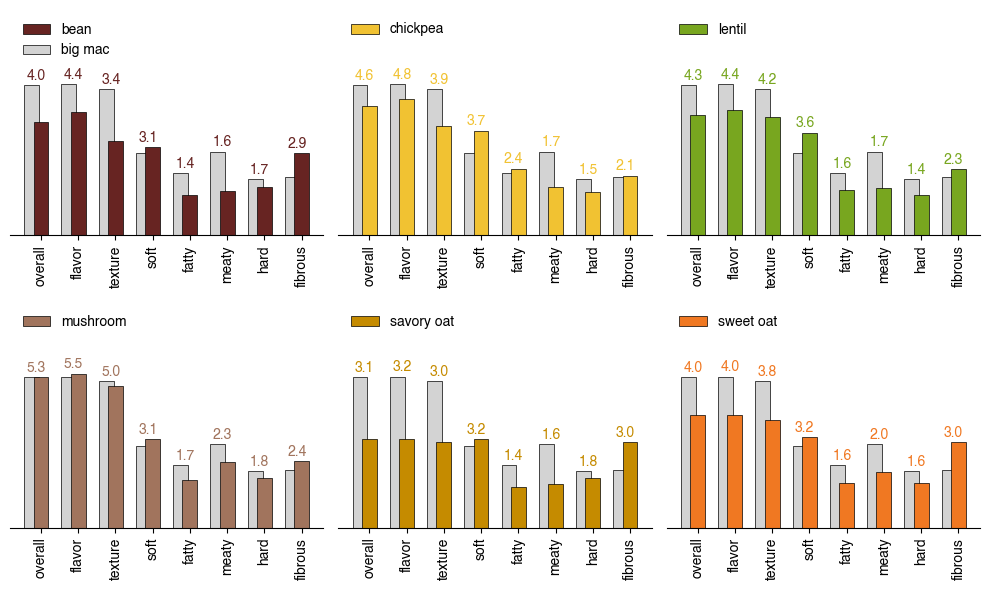

In [29]:
products = ['Bean', 'Chickpea', 'Lentil', 'Mushroom', 'Savory Oat', 'Sweet Oat']
liking_modalities = ['Overall Liking', 'Flavor', 'Texture']
intensity_modalities = [
    'Softness', 'Fattiness',
    'Meatiness', 'Hardness', 'Fibrousness',
]
modalities_short = {
    'Overall Liking': 'overall',
    'Flavor': 'flavor',
    'Texture': 'texture',
    'Softness': 'soft',
    'Fattiness': 'fatty',
    'Fibrousness': 'fibrous',
    'Hardness': 'hard',
    'Meatiness': 'meaty'
}
modalities = liking_modalities + intensity_modalities
burger_colors = {
    'Bean':       '#672422',  # richer red-brown
    'Savory Oat': '#C58B00',  # deeper mustard
    'Mushroom':   '#A1745D',  # warmer, more colorful taupe
    'Chickpea':   '#F1C232',  # brighter golden yellow
    'Lentil':     '#78A61F',  # stronger olive green
    'Sweet Oat':  '#F07822',  # brighter orange
}
bigmac_means = (
    bigmac_question_means.set_index('modality')['mean'].reindex(modalities)
)
x = np.arange(len(modalities))
bar_width = 0.4
bigmac_offset = 0.25

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey=True)
for ax, product in zip(axes.flat, products):
    product_means = (
        survey_question_means.loc[survey_question_means['product'].eq(product)]
        .set_index('modality')['mean']
        .reindex(modalities)
    )
    ax.bar(
        x - bigmac_offset, bigmac_means, width=bar_width,
        color='lightgray', edgecolor='black', zorder=1, linewidth=0.5,
    )
    bars = ax.bar(
        x, product_means, width=bar_width,
        color=burger_colors[product], zorder=2, edgecolor='black',  linewidth=0.5,
    )
    for x_position, burger_mean, bigmac_mean in zip(
        x, product_means.to_numpy(), bigmac_means.to_numpy()
    ):
        if pd.isna(burger_mean):
            continue
        bigmac_is_taller = pd.notna(bigmac_mean) and bigmac_mean > burger_mean
        label_height = bigmac_mean if bigmac_is_taller else burger_mean
        label_x = x_position - bigmac_offset/2# if bigmac_is_taller else x_position
        ax.text(
            label_x, label_height + 0.08, f'{burger_mean:.1f}',
            ha='center', va='bottom', color=burger_colors[product],
            zorder=3,
        )
    ax.set_ylim(0, 8)
    # ax.set_xticks(x, [modality.lower() for modality in modalities])
    ax.set_xticks(x, [modalities_short[modality] for modality in modalities])
    ax.tick_params(axis='x', rotation=90)
    ax.set_yticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if product == 'Bean':
        ax.legend(
            handles=[
                Patch(
                    facecolor=burger_colors[product], edgecolor='black', label=product.lower(),  linewidth=0.5,
                ),
                Patch(facecolor='lightgray', edgecolor='black', label='big mac', linewidth=0.5,), 
            ],
            loc='upper left', ncols=1, frameon=False,
        )
    else:
        ax.legend(
            handles=[
                Patch(
                    facecolor=burger_colors[product], edgecolor='black', label=product.lower(), linewidth=0.5,
                ),
            ],
            loc='upper left', ncols=1, frameon=False,
        )


fig.tight_layout()
fig.savefig('figs/survey_summary.pdf', bbox_inches='tight')

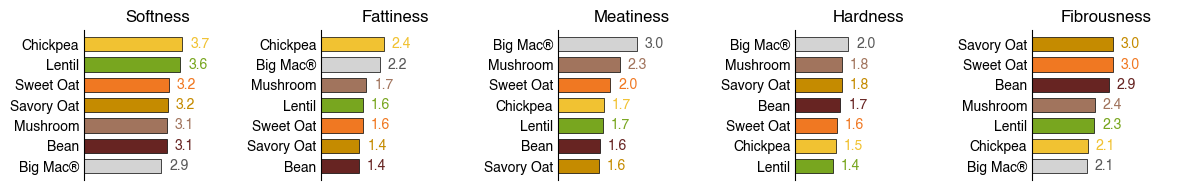

In [30]:
intensity_plot_products = ['Big Mac®'] + products
intensity_plot_colors = ['lightgray'] + [burger_colors[product] for product in products]
product_intensity_means = survey_question_means.pivot(
    index='product', columns='modality', values='mean'
)
bigmac_intensity_means = bigmac_question_means.set_index('modality')['mean']
y = np.arange(len(intensity_plot_products))

fig_intensity, axes_intensity = plt.subplots(
    1, len(intensity_modalities), figsize=(12, 2), sharex=True
)

for ax, modality in zip(axes_intensity, intensity_modalities):
    values = np.array(
        [bigmac_intensity_means[modality]]
        + [product_intensity_means.loc[product, modality] for product in products]
    )
    sort_order = np.argsort(-values, kind='stable')
    sorted_values = values[sort_order]
    sorted_products = np.array(intensity_plot_products)[sort_order]
    sorted_colors = np.array(intensity_plot_colors)[sort_order]
    bars = ax.barh(
        y, sorted_values, color=sorted_colors, edgecolor='black',
        zorder=2, height=0.7, linewidth=0.5,
    )
    ax.invert_yaxis()
    ax.set_title(modality)
    ax.set_xlim(0, 5.6)
    ax.set_xticks([])
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.set_yticks(y, sorted_products)
    ax.tick_params(axis='y', length=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    for bar, value, color in zip(bars, sorted_values, sorted_colors):
        label_color = '0.35' if color == 'lightgray' else color
        ax.text(
            value + 0.3, bar.get_y() + bar.get_height() / 2, f'{value:.1f}',
            ha='left', va='center', color=label_color,
        )

fig_intensity.tight_layout()
plt.show()

## 5.2. Correspondence Analysis

In [31]:
import prince
from matplotlib.lines import Line2D

def extract_cata_selections(survey_data):
    """Return one row per respondent/product/modality/selected CATA attribute."""
    selections = survey_data.loc[
        survey_data['question_type'].eq('CATA'),
        ['Respondent', 'product', 'modality', 'response'],
    ].copy()
    selections['attribute'] = selections['response'].astype(str).str.split(',')
    selections = selections.explode('attribute', ignore_index=True)
    selections['attribute'] = selections['attribute'].str.strip()
    selections = selections.loc[
        selections['attribute'].ne('')
        & selections['attribute'].str.casefold().ne('no response')
    ].copy()
    # Unify the capitalization difference between the two survey waves.
    selections.loc[
        selections['attribute'].str.casefold().eq('weird aftertaste'), 'attribute'
    ] = 'Weird aftertaste'
    return selections.reset_index(drop=True)

survey_cata = extract_cata_selections(survey_long)
bigmac_cata = extract_cata_selections(
    survey_previous_long.loc[survey_previous_long['product'].eq('Big Mac')]
)
cata_all = pd.concat([survey_cata, bigmac_cata], ignore_index=True)

# Combine every burger evaluated in the current and previous surveys for
# the final pooled flavor + texture biplot.
previous_survey_cata = extract_cata_selections(survey_previous_long)
previous_survey_product_order = (
    previous_survey_cata['product'].drop_duplicates().tolist()
)
all_survey_cata = pd.concat(
    [survey_cata, previous_survey_cata], ignore_index=True,
)
current_survey_product_order = (
    survey_cata['product'].drop_duplicates().tolist()
)
all_survey_product_order = list(dict.fromkeys(
    current_survey_product_order + previous_survey_product_order
))
previous_survey_burger_colors = {
    'Big Mac': 'lightgray',
    'Delicious Burger #1': '#4C78A8',
    'Delicious Burger #2': '#F58518',
    'Sustainable Burger #1': '#4F8A5B',
    'Sustainable Burger #2': '#2A9D8F',
    'Nutritious Burger': '#7B6FA6',
}

meat_burger_name_map = {
    'Big Mac': 'Meat Burger 1',
    'Delicious Burger #1': 'Meat Burger 2',
    'Delicious Burger #2': 'Meat Burger 3',
    'Sustainable Burger #2': 'Meat Burger 4',
}
previous_meat_cata = extract_cata_selections(
    survey_previous_long.loc[
        survey_previous_long['product'].isin(meat_burger_name_map)
    ]
)
previous_meat_cata['product'] = previous_meat_cata['product'].replace(
    meat_burger_name_map
)
cata_all_meat = pd.concat([survey_cata, previous_meat_cata], ignore_index=True)
cata_all.head()

,Respondent,product,modality,response,attribute
0,14159994028,Bean,Flavor,"Meaty, Savory, Earthy / Soil, Good aftertaste",Meaty
1,14159994028,Bean,Flavor,"Meaty, Savory, Earthy / Soil, Good aftertaste",Savory
2,14159994028,Bean,Flavor,"Meaty, Savory, Earthy / Soil, Good aftertaste",Earthy / Soil
3,14159994028,Bean,Flavor,"Meaty, Savory, Earthy / Soil, Good aftertaste",Good aftertaste
4,19252977013,Bean,Flavor,Weird Aftertaste,Weird aftertaste


In [32]:
def make_cata_contingency(
    selections, modality=None, include_bigmac=False, pooled=False, row_order=None
): 
    """Create a burger-by-attribute selection-count contingency table."""
    data = selections.copy()
    if modality is not None:
        data = data.loc[data['modality'].eq(modality)].copy()
    if not include_bigmac:
        data = data.loc[~data['product'].eq('Big Mac')].copy()

    if pooled:
        # Preserve modality so identically named flavor/texture attributes stay distinct.
        data['attribute_key'] = data['modality'] + '::' + data['attribute']
    else:
        data['attribute_key'] = data['attribute']

    table = pd.crosstab(data['product'], data['attribute_key'])
    if row_order is None:
        row_order = products + (['Big Mac'] if include_bigmac else [])
    return table.reindex(row_order, fill_value=0).loc[:, lambda x: x.sum().gt(0)]

ca_tables = {
    'Flavor — including Big Mac®': make_cata_contingency(
        cata_all, modality='Flavor', include_bigmac=True
    ),
    'Texture — survey burgers': make_cata_contingency(
        cata_all, modality='Texture', include_bigmac=False
    ),
    'Texture — including Big Mac®': make_cata_contingency(
        cata_all, modality='Texture', include_bigmac=True
    ),
    'Flavor + texture — including Big Mac®': make_cata_contingency(
        cata_all, include_bigmac=True, pooled=True
    ),
    'Flavor + texture — including meat burgers': make_cata_contingency(
        cata_all_meat, pooled=True,
        row_order=products + list(meat_burger_name_map.values()),
    ),
    'Flavor + texture — all burgers': make_cata_contingency(
        all_survey_cata, include_bigmac=True, pooled=True,
        row_order=all_survey_product_order,
    ),
}
{name: table.shape for name, table in ca_tables.items()}

{'Flavor — including Big Mac®': (7, 12),
 'Texture — survey burgers': (6, 15),
 'Texture — including Big Mac®': (7, 15),
 'Flavor + texture — including Big Mac®': (7, 27),
 'Flavor + texture — including meat burgers': (10, 27),
 'Flavor + texture — all burgers': (12, 27)}

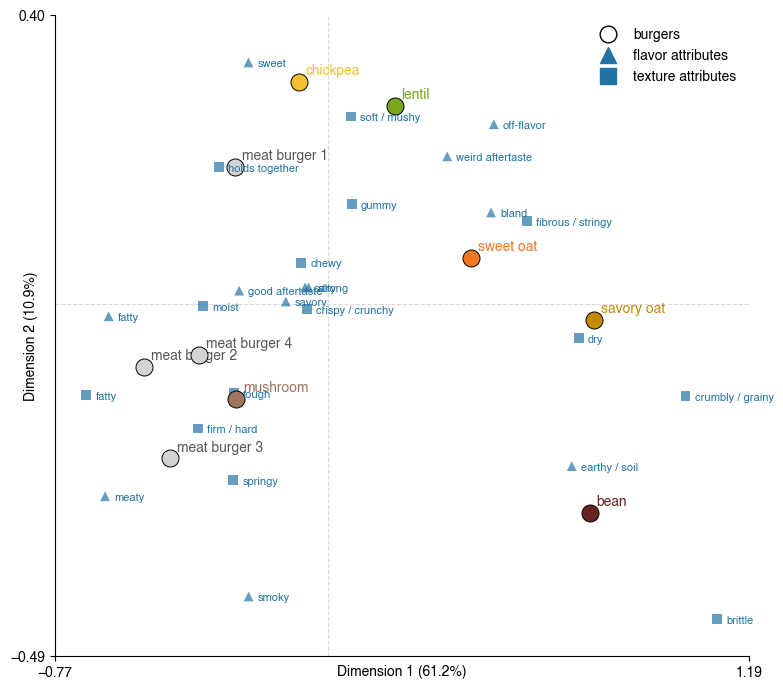

In [33]:
from matplotlib.ticker import StrMethodFormatter

def fit_correspondence_analysis(table):
    model = prince.CA(
        n_components=2, n_iter=10, copy=True,
        check_input=True, random_state=42, engine='sklearn',
    )
    return model.fit(table)

# def plot_ca_biplot(ax, table, title, pooled=False):
fig, ax = plt.subplots(figsize=(8, 7))
ms = 12
title = None
pooled = True
table = ca_tables['Flavor + texture — including meat burgers']
model = fit_correspondence_analysis(table)
row_coordinates = model.row_coordinates(table)
column_coordinates = model.column_coordinates(table)

ax.axhline(0, color='0.85', linewidth=0.8, zorder=0, linestyle='dashed')
ax.axvline(0, color='0.85', linewidth=0.8, zorder=0, linestyle='dashed')

for burger, coordinates in row_coordinates.iterrows():
    is_meat_burger = burger.startswith('Meat Burger')
    display_name = 'Big Mac®' if burger == 'Big Mac' else burger.lower()
    if burger == 'Big Mac' or is_meat_burger:
        color = 'lightgray'
    elif burger in burger_colors:
        color = burger_colors[burger]
    else:
        color = previous_survey_burger_colors.get(burger, '0.65')
    ax.scatter(
        coordinates.iloc[0], coordinates.iloc[1], marker='o', s=150,
        facecolor=color, edgecolor='black', linewidth=0.7, zorder=3,
    )
    ax.annotate(
        display_name, coordinates.iloc[:2], xytext=(5, 5),
        textcoords='offset points',
        color='0.35' if burger == 'Big Mac' or is_meat_burger else color,
        fontweight='bold',
    )

for attribute_key, coordinates in column_coordinates.iterrows():
    if pooled:
        modality, attribute = attribute_key.split('::', 1)
        marker = '^' if modality == 'Flavor' else 's'
        color = '#2274A5' if modality == 'Flavor' else '#2274A5'
        # color = 'gray'
    else:
        attribute = attribute_key
        marker = 'x'
        color = '0.25'
    ax.scatter(
        coordinates.iloc[0], coordinates.iloc[1], marker=marker, s=50, alpha=0.7, edgecolor='None',
        color=color, linewidth=0.9, zorder=2
    )
    xy = coordinates.iloc[:2]
    xy[0] += 0.01
    xy[1] += 0.003
    ax.annotate(
        attribute.lower(), coordinates.iloc[:2], xytext=(4, -5),
        textcoords='offset points', color=color, fontsize=8,
    )

explained = model.percentage_of_variance_
ylim = ax.get_ylim()
ax.set(ylim=[ylim[0],0.4], yticks=[ylim[0],0.4], xticks=ax.get_xlim())
ax.set_xlabel(f'Dimension 1 ({explained[0]:.1f}%)', labelpad=-11)
ax.set_ylabel(f'Dimension 2 ({explained[1]:.1f}%)', labelpad=-20)
ax.set_title(title)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.2f}"))
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.2f}"))

if pooled:
    legend_handles = [
        Line2D([], [], marker='o', linestyle='none', markerfacecolor='white', markersize=ms,
                markeredgecolor='black', label='burgers'),
        Line2D([], [], marker='^', linestyle='none', color='#2274A5', markersize=ms,
                label='flavor attributes'),
        Line2D([], [], marker='s', linestyle='none', color='#2274A5', markersize=ms,
                label='texture attributes'),
    ]
    ax.legend(handles=legend_handles, frameon=False, loc='best')

fig.tight_layout()

fig.savefig('figs/cata.pdf', bbox_inches='tight')

## 5.3. Mixed Effects Models

We model overall liking as a function of flavor liking and texture liking. The three ratings are standardized with `StandardScaler`, so the fixed-effect coefficients are expressed in standard-deviation units. Because every respondent rated multiple burgers, the model includes a respondent-level random intercept to account for each person's general tendency to give higher or lower ratings. For respondent $i$ rating burger $j$, the assumed relationship is

$$
\mathrm{overall}_{ij,z} = \beta_0 + \beta_{\mathrm{flavor}}\,\mathrm{flavor}_{ij,z} + \beta_{\mathrm{texture}}\,\mathrm{texture}_{ij,z} + u_i + \epsilon_{ij},
$$

where $u_i \sim \mathcal{N}(0, \sigma_u^2)$ is the respondent-level random intercept and $\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$ is the observation-level residual.

In [34]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

liking_model_data = (
    survey_numeric.loc[
        survey_numeric['scale'].eq('Liking')
        & survey_numeric['modality'].isin(['Overall Liking', 'Flavor', 'Texture'])
    ]
    .pivot(
        index=['Respondent', 'product'],
        columns='modality',
        values='response_numeric',
    )
    .reset_index()
    .rename(columns={
        'Overall Liking': 'overall_liking',
        'Flavor': 'flavor_liking',
        'Texture': 'texture_liking',
    })
    .dropna(subset=['overall_liking', 'flavor_liking', 'texture_liking'])
)

liking_scaler = StandardScaler()
liking_model_data[['overall_z', 'flavor_z', 'texture_z']] = (
    liking_scaler.fit_transform(
        liking_model_data[['overall_liking', 'flavor_liking', 'texture_liking']]
    )
)

liking_mixed_model = smf.mixedlm(
    'overall_z ~ flavor_z + texture_z',
    data=liking_model_data,
    groups=liking_model_data['Respondent'],
)
liking_mixed_result = liking_mixed_model.fit(reml=True, method='lbfgs')

standardized_betas = liking_mixed_result.fe_params[['flavor_z', 'texture_z']]
standardized_standard_errors = liking_mixed_result.bse_fe[['flavor_z', 'texture_z']]
liking_scale = pd.Series(
    liking_scaler.scale_,
    index=['overall_liking', 'flavor_liking', 'texture_liking'],
)
original_scale_conversion = pd.Series({
    'flavor_z': liking_scale['overall_liking'] / liking_scale['flavor_liking'],
    'texture_z': liking_scale['overall_liking'] / liking_scale['texture_liking'],
})
original_scale_betas = standardized_betas * original_scale_conversion
original_scale_standard_errors = (
    standardized_standard_errors * original_scale_conversion
)

liking_betas = pd.DataFrame({
    'standardized_beta': standardized_betas,
    'original_scale_beta': original_scale_betas,
    'standardized_standard_error': standardized_standard_errors,
    'original_scale_standard_error': original_scale_standard_errors,
    'p_value': liking_mixed_result.pvalues[['flavor_z', 'texture_z']],
}).rename(index={'flavor_z': 'Flavor', 'texture_z': 'Texture'})
liking_betas

/Users/vtac/vtenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/vtac/vtenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,standardized_beta,original_scale_beta,standardized_standard_error,original_scale_standard_error,p_value
Flavor,0.684372,0.650028,0.024398,0.023174,3.943983e-173
Texture,0.263579,0.256678,0.024437,0.023797,4.010423e-27


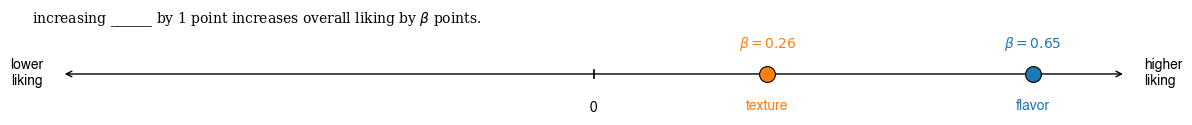

In [35]:
coefficient_specs = [
    ('flavor', 'flavor_z', 'C0'),
    ('texture', 'texture_z', 'C1'),
]
coefficient_values = np.array([
    original_scale_betas[parameter]
    for _, parameter, _ in coefficient_specs
])
axis_limit = np.ceil(np.max(np.abs(coefficient_values)) * 10) / 10 + 0.1

fig_betas, ax_betas = plt.subplots(figsize=(12, 1.5))
ax_betas.set_xlim(-axis_limit, axis_limit)
ax_betas.annotate(
    '', xy=(0.98 * axis_limit, 0), xytext=(-0.98 * axis_limit, 0),
    arrowprops={
        'arrowstyle': '<->', 'color': 'black', 'linewidth': 1,
        'shrinkA': 0, 'shrinkB': 0,
    },
    zorder=0,
)
ax_betas.plot([0, 0], [-0.018, 0.018], color='black', linewidth=1.2)

for label, parameter, color in coefficient_specs:
    beta = original_scale_betas[parameter]
    ax_betas.scatter(
        beta, 0, s=130, marker='o', facecolor=color,
        edgecolor='black', linewidth=0.8, zorder=3,
    )
    ax_betas.annotate(
        rf'$\beta = {beta:.2f}$', (beta, 0), xytext=(0, 15),
        textcoords='offset points', ha='center', va='bottom', color=color,
    )
    ax_betas.annotate(
        label, (beta, 0), xytext=(0, -18),
        textcoords='offset points', ha='center', va='top', color=color,
    )

ax_betas.text(
    -0.02, 1.3,
    r'increasing ______ by 1 point increases overall liking by $\beta$ points.',
    transform=ax_betas.transAxes, ha='left', va='top', fontfamily='serif',
)
ax_betas.text(
    -0.01, 0.35, 'lower\nliking',
    transform=ax_betas.transAxes, ha='right', va='center', clip_on=False,
)
ax_betas.text(
    1.01, 0.35, 'higher\nliking',
    transform=ax_betas.transAxes, ha='left', va='center', clip_on=False,
)
ax_betas.set_ylim(-0.1, 0.2)
ax_betas.set_xticks([0], ['0'])
ax_betas.set_yticks([])
ax_betas.tick_params(axis='x', length=0)
ax_betas.spines[:].set_visible(False)
fig_betas.tight_layout()

fig_betas.savefig('figs/mixeff_1.pdf', bbox_inches='tight')

### Flavor liking and flavor CATA attributes

We next model flavor liking as a function of all flavor-related CATA attributes. Each attribute is represented by a binary indicator: $x_{ijk}=1$ when respondent $i$ selected attribute $k$ for burger $j$, and $x_{ijk}=0$ otherwise. Flavor liking is standardized for model fitting, and the coefficients are subsequently converted back to the original 1–7 liking scale. The assumed relationship is

$$
\mathrm{flavor}_{ij,z}=\beta_0+\sum_{k=1}^{K}\beta_k x_{ijk}+u_i+\epsilon_{ij},
$$

where $u_i \sim \mathcal{N}(0, \sigma_u^2)$ is the respondent-level random intercept and $\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$ is the observation-level residual. Each original-scale coefficient estimates the difference in flavor-liking points associated with selecting that attribute, holding all other included flavor attributes constant.

In [36]:
flavor_liking_data = (
    survey_numeric.loc[
        survey_numeric['scale'].eq('Liking')
        & survey_numeric['modality'].eq('Flavor'),
        ['Respondent', 'product', 'response_numeric'],
    ]
    .rename(columns={'response_numeric': 'flavor_liking'})
)

flavor_cata_selections = survey_cata.loc[
    survey_cata['modality'].eq('Flavor')
]
flavor_attribute_names = sorted(flavor_cata_selections['attribute'].unique())
flavor_cata_binary = (
    pd.crosstab(
        [flavor_cata_selections['Respondent'], flavor_cata_selections['product']],
        flavor_cata_selections['attribute'],
    )
    .clip(upper=1)
    .reset_index()
)

flavor_attribute_model_data = flavor_liking_data.merge(
    flavor_cata_binary, on=['Respondent', 'product'], how='left'
)
flavor_attribute_model_data[flavor_attribute_names] = (
    flavor_attribute_model_data[flavor_attribute_names].fillna(0).astype(int)
)

flavor_liking_scaler = StandardScaler()
flavor_attribute_model_data['flavor_z'] = flavor_liking_scaler.fit_transform(
    flavor_attribute_model_data[['flavor_liking']]
)

# Formula-safe column names keep punctuation and spaces out of the model formula.
flavor_attribute_columns = {
    attribute: f'flavor_attribute_{index}'
    for index, attribute in enumerate(flavor_attribute_names)
}
flavor_attribute_model_data = flavor_attribute_model_data.rename(
    columns=flavor_attribute_columns
)
flavor_attribute_formula = (
    'flavor_z ~ ' + ' + '.join(flavor_attribute_columns.values())
)
flavor_attribute_mixed_model = smf.mixedlm(
    flavor_attribute_formula,
    data=flavor_attribute_model_data,
    groups=flavor_attribute_model_data['Respondent'],
)
flavor_attribute_mixed_result = flavor_attribute_mixed_model.fit(
    reml=True, method='lbfgs'
)

flavor_parameter_names = list(flavor_attribute_columns.values())
flavor_liking_sd = flavor_liking_scaler.scale_[0]
flavor_attribute_betas = pd.DataFrame({
    'attribute': flavor_attribute_names,
    'standardized_beta': flavor_attribute_mixed_result.fe_params[
        flavor_parameter_names
    ].to_numpy(),
    'original_scale_beta': flavor_attribute_mixed_result.fe_params[
        flavor_parameter_names
    ].to_numpy() * flavor_liking_sd,
    'standardized_standard_error': flavor_attribute_mixed_result.bse_fe[
        flavor_parameter_names
    ].to_numpy(),
    'original_scale_standard_error': flavor_attribute_mixed_result.bse_fe[
        flavor_parameter_names
    ].to_numpy() * flavor_liking_sd,
    'p_value': flavor_attribute_mixed_result.pvalues[
        flavor_parameter_names
    ].to_numpy(),
}).set_index('attribute').sort_values('original_scale_beta')
flavor_attribute_betas

/Users/vtac/vtenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/vtac/vtenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,standardized_beta,original_scale_beta,standardized_standard_error,original_scale_standard_error,p_value
attribute,,,,,
Off-flavor,-0.552084,-1.071725,0.083234,0.161576,3.290595e-11
Weird aftertaste,-0.541499,-1.051175,0.081747,0.158691,3.494812e-11
Bland,-0.451825,-0.877098,0.079198,0.153741,1.163298e-08
Earthy / Soil,-0.159675,-0.309966,0.059242,0.115003,7.032512e-03
Salty,0.035215,0.068361,0.068356,0.132694,6.064296e-01
Strong,0.071654,0.139097,0.071561,0.138916,3.166803e-01
Fatty,0.077243,0.149947,0.110451,0.214412,4.843402e-01
Meaty,0.188480,0.365883,0.091570,0.177759,3.955984e-02
Sweet,0.191722,0.372177,0.083364,0.161830,2.145925e-02


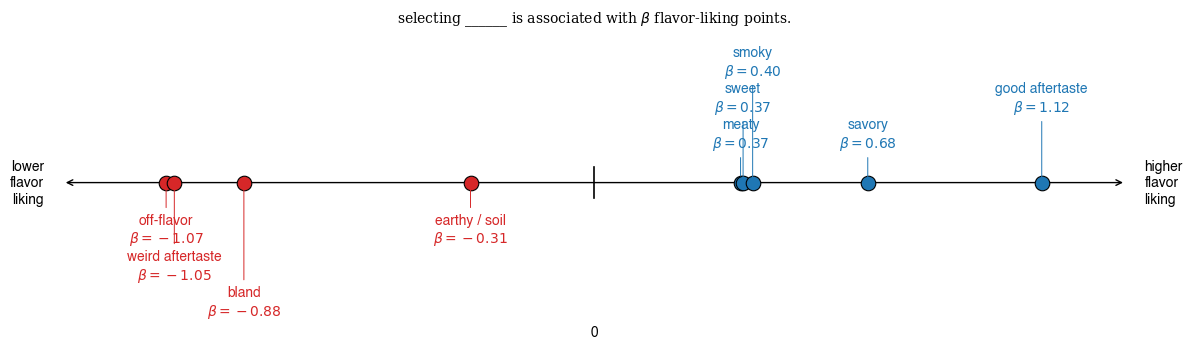

In [37]:
flavor_significance_threshold = 0.05
significant_flavor_betas = flavor_attribute_betas.loc[
    flavor_attribute_betas['p_value'].lt(flavor_significance_threshold)
].copy()

if significant_flavor_betas.empty:
    print(
        f'No flavor CATA attributes meet the p < {flavor_significance_threshold:g} threshold.'
    )
else:
    beta_values = significant_flavor_betas['original_scale_beta']
    axis_limit = np.ceil(np.max(np.abs(beta_values)) * 10) / 10 + 0.15
    fig_flavor_betas, ax_flavor_betas = plt.subplots(figsize=(12, 3.6))
    ax_flavor_betas.set_xlim(-axis_limit, axis_limit)
    ax_flavor_betas.annotate(
        '', xy=(0.98 * axis_limit, 0), xytext=(-0.98 * axis_limit, 0),
        arrowprops={
            'arrowstyle': '<->', 'color': 'black', 'linewidth': 1,
            'shrinkA': 0, 'shrinkB': 0,
        },
        zorder=0,
    )
    ax_flavor_betas.plot([0, 0], [-0.018, 0.018], color='black', linewidth=1.2)

    positive_level = negative_level = 0
    annotation_levels = [22, 48, 74]
    for attribute, row in significant_flavor_betas.iterrows():
        beta = row['original_scale_beta']
        color = 'C0' if beta >= 0 else 'C3'
        if beta >= 0:
            text_offset = annotation_levels[positive_level % len(annotation_levels)]
            positive_level += 1
            vertical_alignment = 'bottom'
        else:
            text_offset = -annotation_levels[negative_level % len(annotation_levels)]
            negative_level += 1
            vertical_alignment = 'top'

        ax_flavor_betas.scatter(
            beta, 0, s=110, marker='o', facecolor=color,
            edgecolor='black', linewidth=0.8, zorder=3,
        )
        ax_flavor_betas.annotate(
            f'{attribute.lower()}\n' + rf'$\beta = {beta:.2f}$',
            (beta, 0), xytext=(0, text_offset), textcoords='offset points',
            ha='center', va=vertical_alignment, color=color,
            arrowprops={'arrowstyle': '-', 'color': color, 'linewidth': 0.7},
        )

    ax_flavor_betas.text(
        0.5, 1.13,
        r'selecting ______ is associated with $\beta$ flavor-liking points.',
        transform=ax_flavor_betas.transAxes, ha='center', va='top',
        fontfamily='serif',
    )
    ax_flavor_betas.text(
        -0.01, 0.5, 'lower\nflavor\nliking',
        transform=ax_flavor_betas.transAxes, ha='right', va='center',
        clip_on=False,
    )
    ax_flavor_betas.text(
        1.01, 0.5, 'higher\nflavor\nliking',
        transform=ax_flavor_betas.transAxes, ha='left', va='center',
        clip_on=False,
    )
    ax_flavor_betas.set_ylim(-0.16, 0.16)
    ax_flavor_betas.set_xticks([0], ['0'])
    ax_flavor_betas.set_yticks([])
    ax_flavor_betas.tick_params(axis='x', length=0)
    ax_flavor_betas.spines[:].set_visible(False)
    fig_flavor_betas.tight_layout()
    plt.show()

significant_flavor_betas

fig_flavor_betas.savefig('figs/mixeff_2.pdf', bbox_inches='tight')

### Texture liking and texture CATA attributes

We apply the same model to texture liking and the texture-related CATA attributes. Each texture attribute is a binary indicator, and texture liking is standardized for model fitting before the coefficients are converted back to the original 1–7 liking scale:

$$
\mathrm{texture}_{ij,z}=\beta_0+\sum_{k=1}^{K}\beta_k x_{ijk}+u_i+\epsilon_{ij}.
$$

Here, $u_i \sim \mathcal{N}(0, \sigma_u^2)$ is the respondent-level random intercept and $\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$ is the residual. Each original-scale coefficient estimates the difference in texture-liking points associated with selecting that attribute, holding all other included texture attributes constant.

In [38]:
texture_liking_data = (
    survey_numeric.loc[
        survey_numeric['scale'].eq('Liking')
        & survey_numeric['modality'].eq('Texture'),
        ['Respondent', 'product', 'response_numeric'],
    ]
    .rename(columns={'response_numeric': 'texture_liking'})
)

texture_cata_selections = survey_cata.loc[
    survey_cata['modality'].eq('Texture')
]
texture_attribute_names = sorted(texture_cata_selections['attribute'].unique())
texture_cata_binary = (
    pd.crosstab(
        [texture_cata_selections['Respondent'], texture_cata_selections['product']],
        texture_cata_selections['attribute'],
    )
    .clip(upper=1)
    .reset_index()
)

texture_attribute_model_data = texture_liking_data.merge(
    texture_cata_binary, on=['Respondent', 'product'], how='left'
)
texture_attribute_model_data[texture_attribute_names] = (
    texture_attribute_model_data[texture_attribute_names].fillna(0).astype(int)
)

texture_liking_scaler = StandardScaler()
texture_attribute_model_data['texture_z'] = texture_liking_scaler.fit_transform(
    texture_attribute_model_data[['texture_liking']]
)

texture_attribute_columns = {
    attribute: f'texture_attribute_{index}'
    for index, attribute in enumerate(texture_attribute_names)
}
texture_attribute_model_data = texture_attribute_model_data.rename(
    columns=texture_attribute_columns
)
texture_attribute_formula = (
    'texture_z ~ ' + ' + '.join(texture_attribute_columns.values())
)
texture_attribute_mixed_model = smf.mixedlm(
    texture_attribute_formula,
    data=texture_attribute_model_data,
    groups=texture_attribute_model_data['Respondent'],
)
texture_attribute_mixed_result = texture_attribute_mixed_model.fit(
    reml=True, method='lbfgs'
)

texture_parameter_names = list(texture_attribute_columns.values())
texture_liking_sd = texture_liking_scaler.scale_[0]
texture_attribute_betas = pd.DataFrame({
    'attribute': texture_attribute_names,
    'standardized_beta': texture_attribute_mixed_result.fe_params[
        texture_parameter_names
    ].to_numpy(),
    'original_scale_beta': texture_attribute_mixed_result.fe_params[
        texture_parameter_names
    ].to_numpy() * texture_liking_sd,
    'standardized_standard_error': texture_attribute_mixed_result.bse_fe[
        texture_parameter_names
    ].to_numpy(),
    'original_scale_standard_error': texture_attribute_mixed_result.bse_fe[
        texture_parameter_names
    ].to_numpy() * texture_liking_sd,
    'p_value': texture_attribute_mixed_result.pvalues[
        texture_parameter_names
    ].to_numpy(),
}).set_index('attribute').sort_values('original_scale_beta')
texture_attribute_betas

/Users/vtac/vtenv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,standardized_beta,original_scale_beta,standardized_standard_error,original_scale_standard_error,p_value
attribute,,,,,
Tough,-0.700614,-1.326531,0.195310,0.369796,3.342532e-04
Crumbly / Grainy,-0.387515,-0.733714,0.078246,0.148150,7.325624e-07
Gummy,-0.317408,-0.600975,0.106478,0.201603,2.873282e-03
Dry,-0.275575,-0.521770,0.091010,0.172317,2.462026e-03
Soft / Mushy,-0.189796,-0.359357,0.074132,0.140360,1.045952e-02
Fibrous / Stringy,-0.141560,-0.268028,0.096029,0.181820,1.404434e-01
Fatty,-0.036111,-0.068371,0.151800,0.287416,8.119717e-01
Sticky,-0.017855,-0.033806,0.136485,0.258418,8.959192e-01
Brittle,0.032844,0.062186,0.108889,0.206168,7.629343e-01


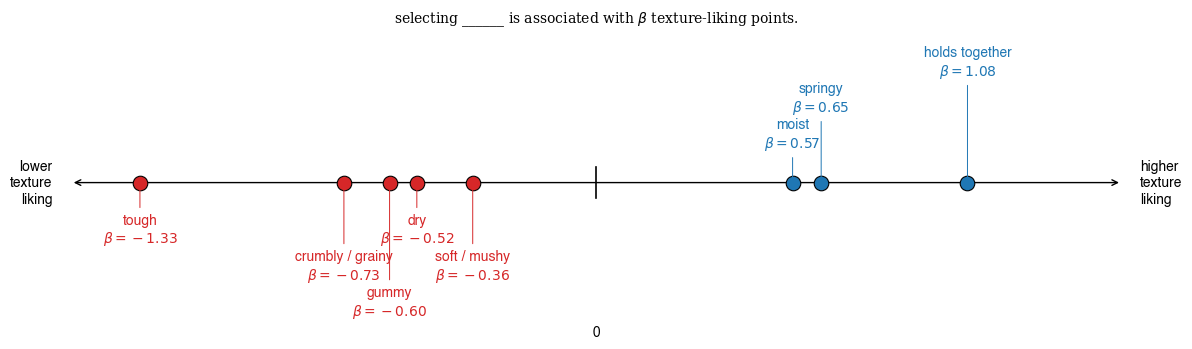

In [39]:
texture_significance_threshold = 0.05
significant_texture_betas = texture_attribute_betas.loc[
    texture_attribute_betas['p_value'].lt(texture_significance_threshold)
].copy()

if significant_texture_betas.empty:
    print(
        f'No texture CATA attributes meet the p < {texture_significance_threshold:g} threshold.'
    )
else:
    beta_values = significant_texture_betas['original_scale_beta']
    axis_limit = np.ceil(np.max(np.abs(beta_values)) * 10) / 10 + 0.15
    fig_texture_betas, ax_texture_betas = plt.subplots(figsize=(12, 3.6))
    ax_texture_betas.set_xlim(-axis_limit, axis_limit)
    ax_texture_betas.annotate(
        '', xy=(0.98 * axis_limit, 0), xytext=(-0.98 * axis_limit, 0),
        arrowprops={
            'arrowstyle': '<->', 'color': 'black', 'linewidth': 1,
            'shrinkA': 0, 'shrinkB': 0,
        },
        zorder=0,
    )
    ax_texture_betas.plot([0, 0], [-0.018, 0.018], color='black', linewidth=1.2)

    positive_level = negative_level = 0
    annotation_levels = [22, 48, 74]
    for attribute, row in significant_texture_betas.iterrows():
        beta = row['original_scale_beta']
        color = 'C0' if beta >= 0 else 'C3'
        if beta >= 0:
            text_offset = annotation_levels[positive_level % len(annotation_levels)]
            positive_level += 1
            vertical_alignment = 'bottom'
        else:
            text_offset = -annotation_levels[negative_level % len(annotation_levels)]
            negative_level += 1
            vertical_alignment = 'top'

        ax_texture_betas.scatter(
            beta, 0, s=110, marker='o', facecolor=color,
            edgecolor='black', linewidth=0.8, zorder=3,
        )
        ax_texture_betas.annotate(
            f'{attribute.lower()}\n' + rf'$\beta = {beta:.2f}$',
            (beta, 0), xytext=(0, text_offset), textcoords='offset points',
            ha='center', va=vertical_alignment, color=color,
            arrowprops={'arrowstyle': '-', 'color': color, 'linewidth': 0.7},
        )

    ax_texture_betas.text(
        0.5, 1.13,
        r'selecting ______ is associated with $\beta$ texture-liking points.',
        transform=ax_texture_betas.transAxes, ha='center', va='top',
        fontfamily='serif',
    )
    ax_texture_betas.text(
        -0.01, 0.5, 'lower\ntexture\nliking',
        transform=ax_texture_betas.transAxes, ha='right', va='center',
        clip_on=False,
    )
    ax_texture_betas.text(
        1.01, 0.5, 'higher\ntexture\nliking',
        transform=ax_texture_betas.transAxes, ha='left', va='center',
        clip_on=False,
    )
    ax_texture_betas.set_ylim(-0.16, 0.16)
    ax_texture_betas.set_xticks([0], ['0'])
    ax_texture_betas.set_yticks([])
    ax_texture_betas.tick_params(axis='x', length=0)
    ax_texture_betas.spines[:].set_visible(False)
    fig_texture_betas.tight_layout()
    plt.show()

significant_texture_betas

fig_texture_betas.savefig('figs/mixeff_3.pdf', bbox_inches='tight')

### Connecting CATA attributes to individual burgers

For each burger and attribute, we calculate $\beta_k(p_{bk}-\bar{p}_k)$, where $p_{bk}$ is the proportion of evaluations of burger $b$ in which attribute $k$ was selected, and $\bar{p}_k$ is its prevalence across all six burgers. Positive values are model-associated contributions above the average burger; negative values are contributions below the average burger. These are descriptive model decompositions rather than causal effects.

In [40]:
def burger_attribute_contributions(
    model_data, attribute_columns, beta_table, significant_beta_table,
    liking_column, burger_order,
):
    inverse_attribute_columns = {
        model_column: attribute
        for attribute, model_column in attribute_columns.items()
    }
    model_columns = list(attribute_columns.values())
    prevalence = (
        model_data.groupby('product')[model_columns].mean()
        .rename(columns=inverse_attribute_columns)
        .reindex(burger_order)
    )
    overall_prevalence = (
        model_data[model_columns].mean().rename(index=inverse_attribute_columns)
    )
    significant_attributes = significant_beta_table.index.tolist()
    contributions = (
        prevalence[significant_attributes]
        .sub(overall_prevalence[significant_attributes], axis='columns')
        .mul(
            beta_table.loc[significant_attributes, 'original_scale_beta'],
            axis='columns',
        )
    )
    observed_means = (
        model_data.groupby('product')[liking_column].mean().reindex(burger_order)
    )
    return prevalence, contributions, observed_means

(
    flavor_attribute_prevalence,
    flavor_burger_contributions,
    flavor_burger_liking_means,
) = burger_attribute_contributions(
    flavor_attribute_model_data, flavor_attribute_columns,
    flavor_attribute_betas, significant_flavor_betas,
    'flavor_liking', products,
)
(
    texture_attribute_prevalence,
    texture_burger_contributions,
    texture_burger_liking_means,
) = burger_attribute_contributions(
    texture_attribute_model_data, texture_attribute_columns,
    texture_attribute_betas, significant_texture_betas,
    'texture_liking', products,
)

In [41]:
flavor_reference_burger = 'Savory Oat'
flavor_target_burger = 'Mushroom'

flavor_pairwise_contributions = pd.DataFrame({
    'Mushroom prevalence': flavor_attribute_prevalence.loc[
        flavor_target_burger
    ],
    'Savory Oat prevalence': flavor_attribute_prevalence.loc[
        flavor_reference_burger
    ],
    'original_scale_beta': flavor_attribute_betas['original_scale_beta'],
    'p_value': flavor_attribute_betas['p_value'],
})
flavor_pairwise_contributions['prevalence_difference'] = (
    flavor_pairwise_contributions['Mushroom prevalence']
    - flavor_pairwise_contributions['Savory Oat prevalence']
)
flavor_pairwise_contributions['predicted_liking_contribution'] = (
    flavor_pairwise_contributions['original_scale_beta']
    * flavor_pairwise_contributions['prevalence_difference']
)
flavor_pairwise_contributions['statistically_significant'] = (
    flavor_pairwise_contributions['p_value'].lt(flavor_significance_threshold)
)
flavor_pairwise_contributions = flavor_pairwise_contributions.sort_values(
    'predicted_liking_contribution', key=np.abs, ascending=False
)

flavor_predicted_difference = flavor_pairwise_contributions[
    'predicted_liking_contribution'
].sum()
flavor_predicted_significant_only_difference = (
    flavor_pairwise_contributions.loc[
        flavor_pairwise_contributions['statistically_significant'],
        'predicted_liking_contribution',
    ].sum()
)
flavor_observed_difference = (
    flavor_burger_liking_means.loc[flavor_target_burger]
    - flavor_burger_liking_means.loc[flavor_reference_burger]
)
flavor_pairwise_summary = pd.Series({
    'comparison': 'Mushroom - Savory Oat',
    'Mushroom observed mean': flavor_burger_liking_means.loc[
        flavor_target_burger
    ],
    'Savory Oat observed mean': flavor_burger_liking_means.loc[
        flavor_reference_burger
    ],
    'observed flavor-liking difference': flavor_observed_difference,
    'predicted difference (all attributes)': flavor_predicted_difference,
    'predicted difference (significant attributes only)': (
        flavor_predicted_significant_only_difference
    ),
})

display(flavor_pairwise_summary.to_frame('value'))
flavor_pairwise_contributions

,value
comparison,Mushroom - Savory Oat
Mushroom observed mean,5.475248
Savory Oat observed mean,3.158416
observed flavor-liking difference,2.316832
predicted difference (all attributes),1.420591
predicted difference (significant attributes only),1.392141


,Mushroom prevalence,Savory Oat prevalence,original_scale_beta,p_value,prevalence_difference,predicted_liking_contribution,statistically_significant
Good aftertaste,0.376238,0.069307,1.119591,1.432509e-15,0.306931,0.343637,True
Off-flavor,0.049505,0.277228,-1.071725,3.290595e-11,-0.227723,0.244056,True
Savory,0.633663,0.306931,0.684195,5.009067e-08,0.326733,0.223549,True
Bland,0.099010,0.316832,-0.877098,1.163298e-08,-0.217822,0.191051,True
Weird aftertaste,0.079208,0.257426,-1.051175,3.494812e-11,-0.178218,0.187338,True
Meaty,0.287129,0.059406,0.365883,3.955984e-02,0.227723,0.083320,True
Smoky,0.297030,0.089109,0.396123,6.417773e-03,0.207921,0.082362,True
Earthy / Soil,0.386139,0.504950,-0.309966,7.032512e-03,-0.118812,0.036828,True
Strong,0.227723,0.089109,0.139097,3.166803e-01,0.138614,0.019281,False
Fatty,0.099010,0.019802,0.149947,4.843402e-01,0.079208,0.011877,False


### Observed and model-predicted burger scores

For each model, predictions use the fixed-effects component and are converted back to the original 1–7 liking scale. The figure compares each burger's raw observed mean with its raw model-predicted mean for overall, flavor, and texture liking.

overall: maximum absolute error = 0.112; mean absolute error = 0.080
texture: maximum absolute error = 0.374; mean absolute error = 0.201
flavor: maximum absolute error = 0.641; mean absolute error = 0.244


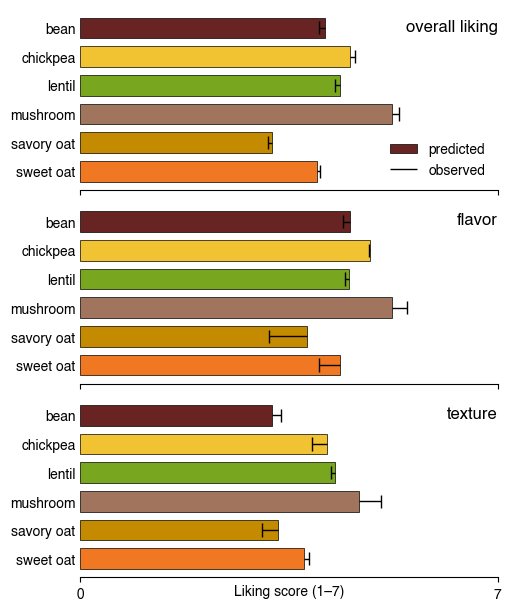

In [46]:
liking_mean = pd.Series(
    liking_scaler.mean_,
    index=['overall_liking', 'flavor_liking', 'texture_liking'],
)
liking_model_data['predicted_overall_liking'] = (
    liking_mixed_result.predict(liking_model_data)
    * liking_scale['overall_liking']
    + liking_mean['overall_liking']
)
flavor_attribute_model_data['predicted_flavor_liking'] = (
    flavor_attribute_mixed_result.predict(flavor_attribute_model_data)
    * flavor_liking_scaler.scale_[0]
    + flavor_liking_scaler.mean_[0]
)
texture_attribute_model_data['predicted_texture_liking'] = (
    texture_attribute_mixed_result.predict(texture_attribute_model_data)
    * texture_liking_scaler.scale_[0]
    + texture_liking_scaler.mean_[0]
)

def burger_observed_predicted_differences(
    data, observed_column, predicted_column, burger_order,
):
    burger_means = (
        data.groupby('product')[[observed_column, predicted_column]].mean()
        .reindex(burger_order)
        .rename(columns={
            observed_column: 'observed_mean',
            predicted_column: 'predicted_mean',
        })
    )
    burger_means['observed_difference'] = (
        burger_means['observed_mean'] - burger_means['observed_mean'].mean()
    )
    burger_means['predicted_difference'] = (
        burger_means['predicted_mean'] - burger_means['predicted_mean'].mean()
    )
    return burger_means

overall_burger_prediction = burger_observed_predicted_differences(
    liking_model_data, 'overall_liking', 'predicted_overall_liking', products,
)
flavor_burger_prediction = burger_observed_predicted_differences(
    flavor_attribute_model_data, 'flavor_liking',
    'predicted_flavor_liking', products,
)
texture_burger_prediction = burger_observed_predicted_differences(
    texture_attribute_model_data, 'texture_liking',
    'predicted_texture_liking', products,
)
burger_liking_predictions = pd.concat(
    {
        'Overall liking': overall_burger_prediction,
        'Flavor liking': flavor_burger_prediction,
        'Texture liking': texture_burger_prediction,
    },
    names=['outcome', 'product'],
)

prediction_panels = [
    ('overall liking', overall_burger_prediction),
    ('flavor', flavor_burger_prediction),
    ('texture', texture_burger_prediction),
]

def print_prediction_errors(category_predictions):
    """Print product-level errors between predicted and observed means."""
    for category, panel_data in category_predictions:
        absolute_errors = (
            panel_data['predicted_mean'] - panel_data['observed_mean']
        ).abs()
        print(
            f'{category}: maximum absolute error = {absolute_errors.max():.3f}; '
            f'mean absolute error = {absolute_errors.mean():.3f}'
        )

print_prediction_errors([
    ('overall', overall_burger_prediction),
    ('texture', texture_burger_prediction),
    ('flavor', flavor_burger_prediction),
])
fig_burger_predictions, axes_burger_predictions = plt.subplots(
    3, 1, figsize=(5, 6), sharex=True, constrained_layout=True,
)
bar_height = 0.72
burger_positions = np.arange(len(products))
panel_colors = [burger_colors[burger] for burger in products]

for ax, (outcome_name, panel_data) in zip(
    axes_burger_predictions, prediction_panels
):
    predicted_bars = ax.barh(
        burger_positions, panel_data['predicted_mean'],
        height=bar_height, color=panel_colors, edgecolor='black',
        linewidth=0.5, label='Predicted',
    )

    # Draw a one-ended, error-bar-style whisker from the predicted score
    # to the observed score, with the cap only at the observed endpoint.
    cap_half_height = bar_height * 0.32
    ax.hlines(
        burger_positions,
        panel_data['predicted_mean'], panel_data['observed_mean'],
        colors='black', linewidth=1, zorder=3,
    )
    ax.vlines(
        panel_data['observed_mean'],
        burger_positions - cap_half_height,
        burger_positions + cap_half_height,
        colors='black', linewidth=1, label='Observed', zorder=3,
    )
    # ax.set_yticks(burger_positions, products)
    ax.set_yticks(burger_positions, [product.lower() for product in products])
    ax.invert_yaxis()
    ax.set_xlim(0, 7)
    ax.set_xticks([0,7])
    ax.set_title(outcome_name, x=1.0, y=0.9, va='top', ha='right')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

handles, labels = axes_burger_predictions[0].get_legend_handles_labels()
legend_order = [labels.index('Predicted'), labels.index('Observed')]
axes_burger_predictions[0].legend(
    [handles[i] for i in legend_order],
    [labels[i].lower() for i in legend_order],
    frameon=False, loc='lower right',
)
axes_burger_predictions[-1].set_xlabel(
    'Liking score (1–7)', labelpad=-12
)
plt.show()

burger_liking_predictions

fig_burger_predictions.savefig('figs/predictions.pdf', bbox_inches='tight')

### Validation on two burgers from the previous survey

In [47]:
def prepare_validation_cata_data(
    validation_liking, validation_selections, modality, attribute_columns,
    liking_column,
):
    modality_selections = validation_selections.loc[
        validation_selections['modality'].eq(modality)
    ]
    binary_attributes = (
        pd.crosstab(
            [
                modality_selections['Respondent'],
                modality_selections['product'],
            ],
            modality_selections['attribute'],
        )
        .clip(upper=1)
        .reset_index()
    )
    data = validation_liking[
        ['Respondent', 'product', liking_column]
    ].merge(binary_attributes, on=['Respondent', 'product'], how='left')

    # Ignore attributes unseen during training and add any missing training columns as zero.
    for attribute in attribute_columns:
        if attribute not in data:
            data[attribute] = 0
    data[list(attribute_columns)] = (
        data[list(attribute_columns)].fillna(0).astype(int)
    )
    return data.rename(columns=attribute_columns)

overall: maximum absolute error = 0.185; mean absolute error = 0.125
texture: maximum absolute error = 0.789; mean absolute error = 0.519
flavor: maximum absolute error = 0.337; mean absolute error = 0.200


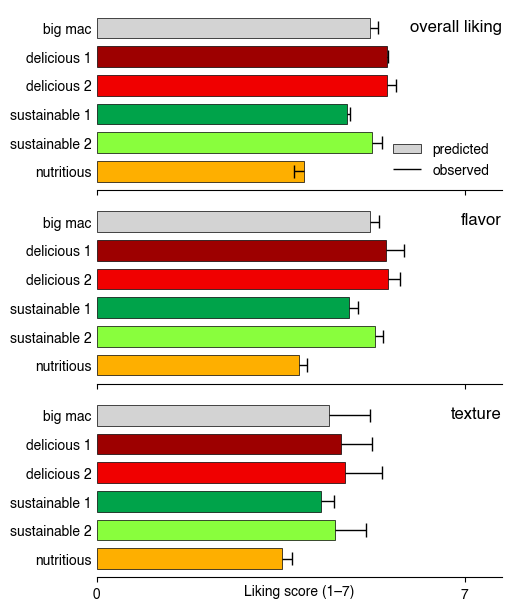

In [48]:
all_validation_products = [
    'Big Mac', 'Delicious Burger #1', 'Delicious Burger #2',
    'Sustainable Burger #1', 'Sustainable Burger #2', 'Nutritious Burger',
]
all_validation_display_names = {
    'Big Mac': 'Big Mac®',
    **{product: product for product in all_validation_products[1:]},
}
all_validation_colors = {
    'Big Mac': 'lightgray',
    'Delicious Burger #1': np.array((158, 0, 0))/256,
    'Delicious Burger #2': np.array((241, 0, 0))/256,
    'Sustainable Burger #1': np.array((0, 164, 74))/256,
    'Sustainable Burger #2': np.array((138, 255, 61))/256,
    'Nutritious Burger': np.array((255, 176, 0))/256,
}

all_validation_numeric = survey_previous_long.loc[
    survey_previous_long['product'].isin(all_validation_products)
    & survey_previous_long['response_numeric'].notna()
].copy()
all_validation_numeric['response_numeric'] = (
    all_validation_numeric['response_numeric'].astype(int)
)
all_validation_liking_data = (
    all_validation_numeric.loc[
        all_validation_numeric['question_type'].eq('Likert')
        & all_validation_numeric['modality'].isin(
            ['Overall Liking', 'Flavor', 'Texture']
        )
    ]
    .pivot(
        index=['Respondent', 'product'], columns='modality',
        values='response_numeric',
    )
    .reset_index()
    .rename(columns={
        'Overall Liking': 'overall_liking',
        'Flavor': 'flavor_liking',
        'Texture': 'texture_liking',
    })
    .dropna(subset=['overall_liking', 'flavor_liking', 'texture_liking'])
)
all_validation_liking_data[['overall_z', 'flavor_z', 'texture_z']] = (
    liking_scaler.transform(
        all_validation_liking_data[
            ['overall_liking', 'flavor_liking', 'texture_liking']
        ]
    )
)
all_validation_liking_data['predicted_overall_liking'] = (
    liking_mixed_result.predict(all_validation_liking_data)
    * liking_scale['overall_liking'] + liking_mean['overall_liking']
)

all_validation_cata = extract_cata_selections(
    survey_previous_long.loc[
        survey_previous_long['product'].isin(all_validation_products)
    ]
)
all_validation_flavor_data = prepare_validation_cata_data(
    all_validation_liking_data, all_validation_cata, 'Flavor',
    flavor_attribute_columns, 'flavor_liking',
)
all_validation_flavor_data['predicted_flavor_liking'] = (
    flavor_attribute_mixed_result.predict(all_validation_flavor_data)
    * flavor_liking_scaler.scale_[0] + flavor_liking_scaler.mean_[0]
)
all_validation_texture_data = prepare_validation_cata_data(
    all_validation_liking_data, all_validation_cata, 'Texture',
    texture_attribute_columns, 'texture_liking',
)
all_validation_texture_data['predicted_texture_liking'] = (
    texture_attribute_mixed_result.predict(all_validation_texture_data)
    * texture_liking_scaler.scale_[0] + texture_liking_scaler.mean_[0]
)

def all_validation_burger_means(data, observed_column, predicted_column):
    return (
        data.groupby('product')[[observed_column, predicted_column]].mean()
        .reindex(all_validation_products)
        .rename(columns={
            observed_column: 'observed_mean',
            predicted_column: 'predicted_mean',
        })
    )

all_validation_overall_prediction = all_validation_burger_means(
    all_validation_liking_data, 'overall_liking', 'predicted_overall_liking'
)
all_validation_flavor_prediction = all_validation_burger_means(
    all_validation_flavor_data, 'flavor_liking', 'predicted_flavor_liking'
)
all_validation_texture_prediction = all_validation_burger_means(
    all_validation_texture_data, 'texture_liking', 'predicted_texture_liking'
)
all_validation_burger_predictions = pd.concat(
    {
        'Overall liking': all_validation_overall_prediction,
        'Flavor liking': all_validation_flavor_prediction,
        'Texture liking': all_validation_texture_prediction,
    }, names=['outcome', 'product'],
)

all_validation_panels = [
    ('overall liking', all_validation_overall_prediction),
    ('flavor', all_validation_flavor_prediction),
    ('texture', all_validation_texture_prediction),
]

print_prediction_errors([
    ('overall', all_validation_overall_prediction),
    ('texture', all_validation_texture_prediction),
    ('flavor', all_validation_flavor_prediction),
])
fig_all_validation, axes_all_validation = plt.subplots(
    3, 1, figsize=(5, 6), sharex=True, constrained_layout=True,
)
all_validation_bar_height = 0.72
all_validation_positions = np.arange(len(all_validation_products))
all_validation_panel_colors = [
    all_validation_colors[product] for product in all_validation_products
]
for ax, (outcome_name, panel_data) in zip(
    axes_all_validation, all_validation_panels
):
    predicted_bars = ax.barh(
        all_validation_positions, panel_data['predicted_mean'],
        height=all_validation_bar_height, color=all_validation_panel_colors,
        edgecolor='black', linewidth=0.5, label='Predicted',
    )

    # Draw a one-ended, error-bar-style whisker from the predicted score
    # to the observed score, with the cap only at the observed endpoint.
    cap_half_height = all_validation_bar_height * 0.32
    ax.hlines(
        all_validation_positions,
        panel_data['predicted_mean'], panel_data['observed_mean'],
        colors='black', linewidth=1, zorder=3,
    )
    ax.vlines(
        panel_data['observed_mean'],
        all_validation_positions - cap_half_height,
        all_validation_positions + cap_half_height,
        colors='black', linewidth=1, label='Observed', zorder=3,
    )
    short_names = ['big mac', 'delicious 1', 'delicious 2', 'sustainable 1', 'sustainable 2', 'nutritious']
    ax.set_yticks(
        all_validation_positions,
        short_names,
    )
    ax.invert_yaxis()
    ax.set_xlim(0, 7.7)
    ax.set_xticks([0, 7])
    ax.set_title(outcome_name, x=1.0, y=0.9, va='top', ha='right')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

handles, labels = axes_all_validation[0].get_legend_handles_labels()
legend_order = [labels.index('Predicted'), labels.index('Observed')]
axes_all_validation[0].legend(
    [handles[i] for i in legend_order],
    [labels[i].lower() for i in legend_order],
    frameon=False, loc='lower right',
)
axes_all_validation[-1].set_xlabel(
    'Liking score (1–7)', labelpad=-12
)
plt.show()

all_validation_burger_predictions

fig_all_validation.savefig('figs/predictions_validation.pdf', bbox_inches='tight')

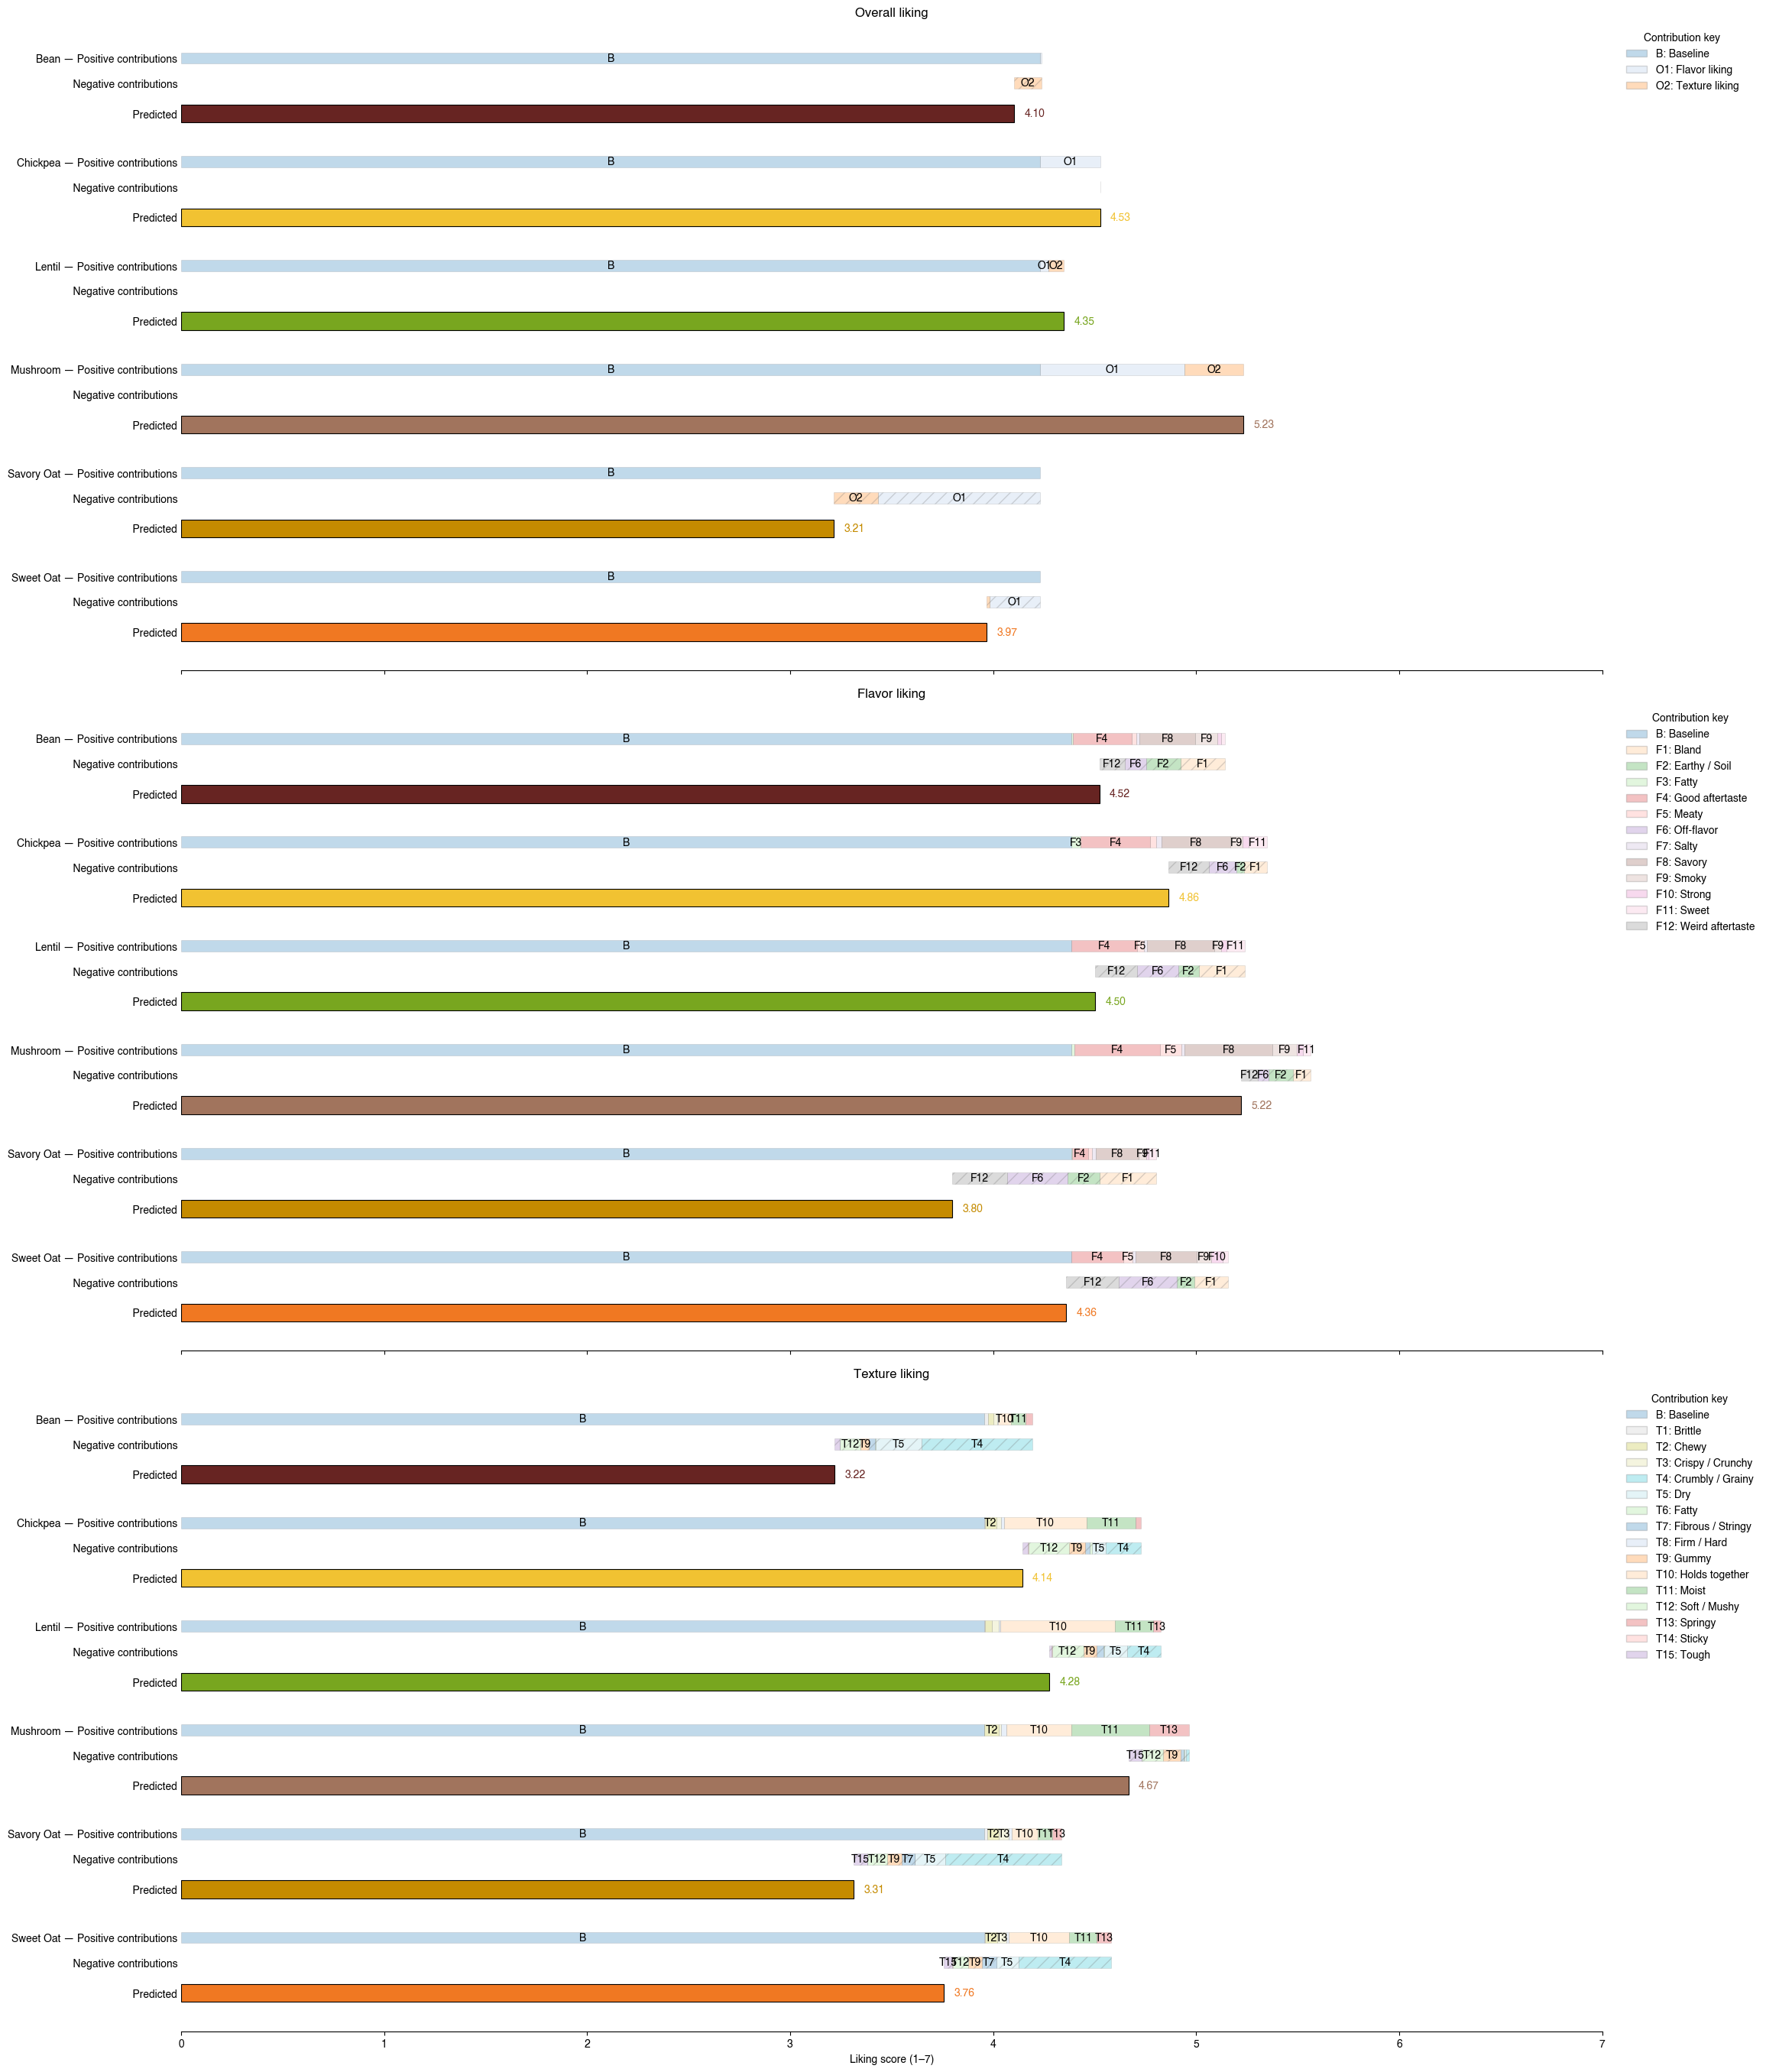

{'Overall liking':             Baseline  Flavor liking  Texture liking
 product                                            
 Bean        4.232673       0.006436       -0.135963
 Chickpea    4.232673       0.296052       -0.001271
 Lentil      4.232673       0.038616        0.077512
 Mushroom    4.232673       0.707951        0.293528
 Savory Oat  4.232673      -0.798054       -0.219828
 Sweet Oat   4.232673      -0.251001       -0.013978,
 'Flavor liking':             Baseline     Bland  Earthy / Soil     Fatty  Good aftertaste  \
 product                                                                    
 Bean        4.386139 -0.217103      -0.168794  0.007423         0.288212   
 Chickpea    4.386139 -0.112894      -0.036828  0.044539         0.343637   
 Lentil      4.386139 -0.225787      -0.101276  0.000000         0.321467   
 Mushroom    4.386139 -0.086841      -0.119690  0.014846         0.421232   
 Savory Oat  4.386139 -0.277892      -0.156518  0.002969         0.077595   
 

In [45]:
def mean_prediction_contributions(
    data, result, outcome_mean, outcome_scale, attribute_columns=None,
    burger_order=None,
):
    """Return burger-level additive fixed-effect contributions in raw points."""
    pieces = pd.DataFrame(index=data.index)
    pieces['Baseline'] = outcome_mean + outcome_scale * result.fe_params['Intercept']
    if attribute_columns is None:
        predictor_labels = {
            'flavor_z': 'Flavor liking',
            'texture_z': 'Texture liking',
        }
    else:
        predictor_labels = {
            model_column: attribute
            for attribute, model_column in attribute_columns.items()
        }
    for model_column, label in predictor_labels.items():
        pieces[label] = (
            outcome_scale * result.fe_params[model_column] * data[model_column]
        )
    pieces['product'] = data['product'].to_numpy()
    if burger_order is None:
        burger_order = all_validation_products
    return pieces.groupby('product').mean().reindex(burger_order)
row_offsets = [0.0, 0.70, 1.55]
group_spacing = 2.90
overall_validation_contributions = mean_prediction_contributions(
    all_validation_liking_data, liking_mixed_result,
    liking_mean['overall_liking'], liking_scale['overall_liking'],
)
flavor_validation_contributions = mean_prediction_contributions(
    all_validation_flavor_data, flavor_attribute_mixed_result,
    flavor_liking_scaler.mean_[0], flavor_liking_scaler.scale_[0],
    flavor_attribute_columns,
)
texture_validation_contributions = mean_prediction_contributions(
    all_validation_texture_data, texture_attribute_mixed_result,
    texture_liking_scaler.mean_[0], texture_liking_scaler.scale_[0],
    texture_attribute_columns,
)
validation_decomposition_panels = [
    ('Overall liking', all_validation_overall_prediction, overall_validation_contributions),
    ('Flavor liking', all_validation_flavor_prediction, flavor_validation_contributions),
    ('Texture liking', all_validation_texture_prediction, texture_validation_contributions),
]
all_component_names = list(dict.fromkeys(
    component for _, _, table in validation_decomposition_panels
    for component in table.columns
))
component_colors = {
    component: plt.get_cmap('tab20')(index % 20)
    for index, component in enumerate(all_component_names)
}


current_overall_contributions = mean_prediction_contributions(
    liking_model_data, liking_mixed_result,
    liking_mean['overall_liking'], liking_scale['overall_liking'],
    burger_order=products,
)
current_flavor_contributions = mean_prediction_contributions(
    flavor_attribute_model_data, flavor_attribute_mixed_result,
    flavor_liking_scaler.mean_[0], flavor_liking_scaler.scale_[0],
    flavor_attribute_columns,
    burger_order=products,
)
current_texture_contributions = mean_prediction_contributions(
    texture_attribute_model_data, texture_attribute_mixed_result,
    texture_liking_scaler.mean_[0], texture_liking_scaler.scale_[0],
    texture_attribute_columns,
    burger_order=products,
)
current_decomposition_panels = [
    ('Overall liking', overall_burger_prediction, current_overall_contributions),
    ('Flavor liking', flavor_burger_prediction, current_flavor_contributions),
    ('Texture liking', texture_burger_prediction, current_texture_contributions),
]
for outcome_name, prediction_table, contribution_table in current_decomposition_panels:
    if not np.allclose(
        contribution_table.sum(axis=1), prediction_table['predicted_mean']
    ):
        raise ValueError(f'{outcome_name} contributions do not reconstruct predictions.')

current_max_positive_endpoint = max(
    table.clip(lower=0).sum(axis=1).max()
    for _, _, table in current_decomposition_panels
)
current_decomposition_xmax = max(
    7.0, np.ceil(current_max_positive_endpoint * 2) / 2 + 0.5
)
fig_current_decomposition, axes_current_decomposition = plt.subplots(
    3, 1, figsize=(23, 27), sharex=True, constrained_layout=True,
)

for ax, (outcome_name, prediction_table, contribution_table) in zip(
    axes_current_decomposition, current_decomposition_panels
):
    tick_positions, tick_labels = [], []
    code_prefix = {
        'Overall liking': 'O', 'Flavor liking': 'F', 'Texture liking': 'T'
    }[outcome_name]
    component_codes = {'Baseline': 'B'}
    component_codes.update({
        component: f'{code_prefix}{index}'
        for index, component in enumerate(
            [name for name in contribution_table.columns if name != 'Baseline'],
            start=1,
        )
    })
    for burger_index, burger in enumerate(products):
        base_y = burger_index * group_spacing
        burger_color = burger_colors[burger]
        predicted = prediction_table.loc[burger, 'predicted_mean']
        pieces = contribution_table.loc[burger]

        positive_cursor = 0.0
        for component, value in pieces.items():
            if value <= 1e-10:
                continue
            ax.barh(base_y + row_offsets[0], value, left=positive_cursor,
                    height=0.32, color=component_colors[component], alpha=0.28,
                    edgecolor='0.45', linewidth=0.45)
            if value >= 0.035:
                ax.text(positive_cursor + value / 2, base_y + row_offsets[0],
                        component_codes[component], ha='center', va='center',
                        clip_on=True)
            positive_cursor += value

        negative_cursor = positive_cursor
        for component, value in pieces.items():
            if value >= -1e-10:
                continue
            segment_left = negative_cursor + value
            ax.barh(base_y + row_offsets[1], -value, left=segment_left,
                    height=0.32, color=component_colors[component], alpha=0.28,
                    edgecolor='0.45', linewidth=0.45, hatch='//')
            if -value >= 0.035:
                ax.text(segment_left - value / 2, base_y + row_offsets[1],
                        component_codes[component], ha='center', va='center',
                        clip_on=True)
            negative_cursor += value

        ax.barh(base_y + row_offsets[2], predicted, height=0.50,
                color=burger_color, edgecolor='black', linewidth=0.8)
        ax.text(predicted + 0.05, base_y + row_offsets[2], f'{predicted:.2f}',
                ha='left', va='center', color=burger_color)
        tick_positions.extend(base_y + np.array(row_offsets))
        tick_labels.extend([
            f'{burger} — Positive contributions',
            '    Negative contributions', '    Predicted',
        ])

    ax.set_yticks(tick_positions, tick_labels)
    ax.invert_yaxis()
    ax.set_xlim(0, current_decomposition_xmax)
    ax.set_title(outcome_name)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    component_key = [
        Patch(
            facecolor=component_colors[component], edgecolor='0.45', alpha=0.28,
            label=f'{component_codes[component]}: {component}',
        )
        for component in contribution_table.columns
    ]
    ax.legend(
        handles=component_key, frameon=False, loc='upper left',
        bbox_to_anchor=(1.01, 1), title='Contribution key',
    )

axes_current_decomposition[-1].set_xlabel('Liking score (1–7)')
plt.show()

current_prediction_contributions = {
    outcome_name: table for outcome_name, _, table in current_decomposition_panels
}
current_prediction_contributions

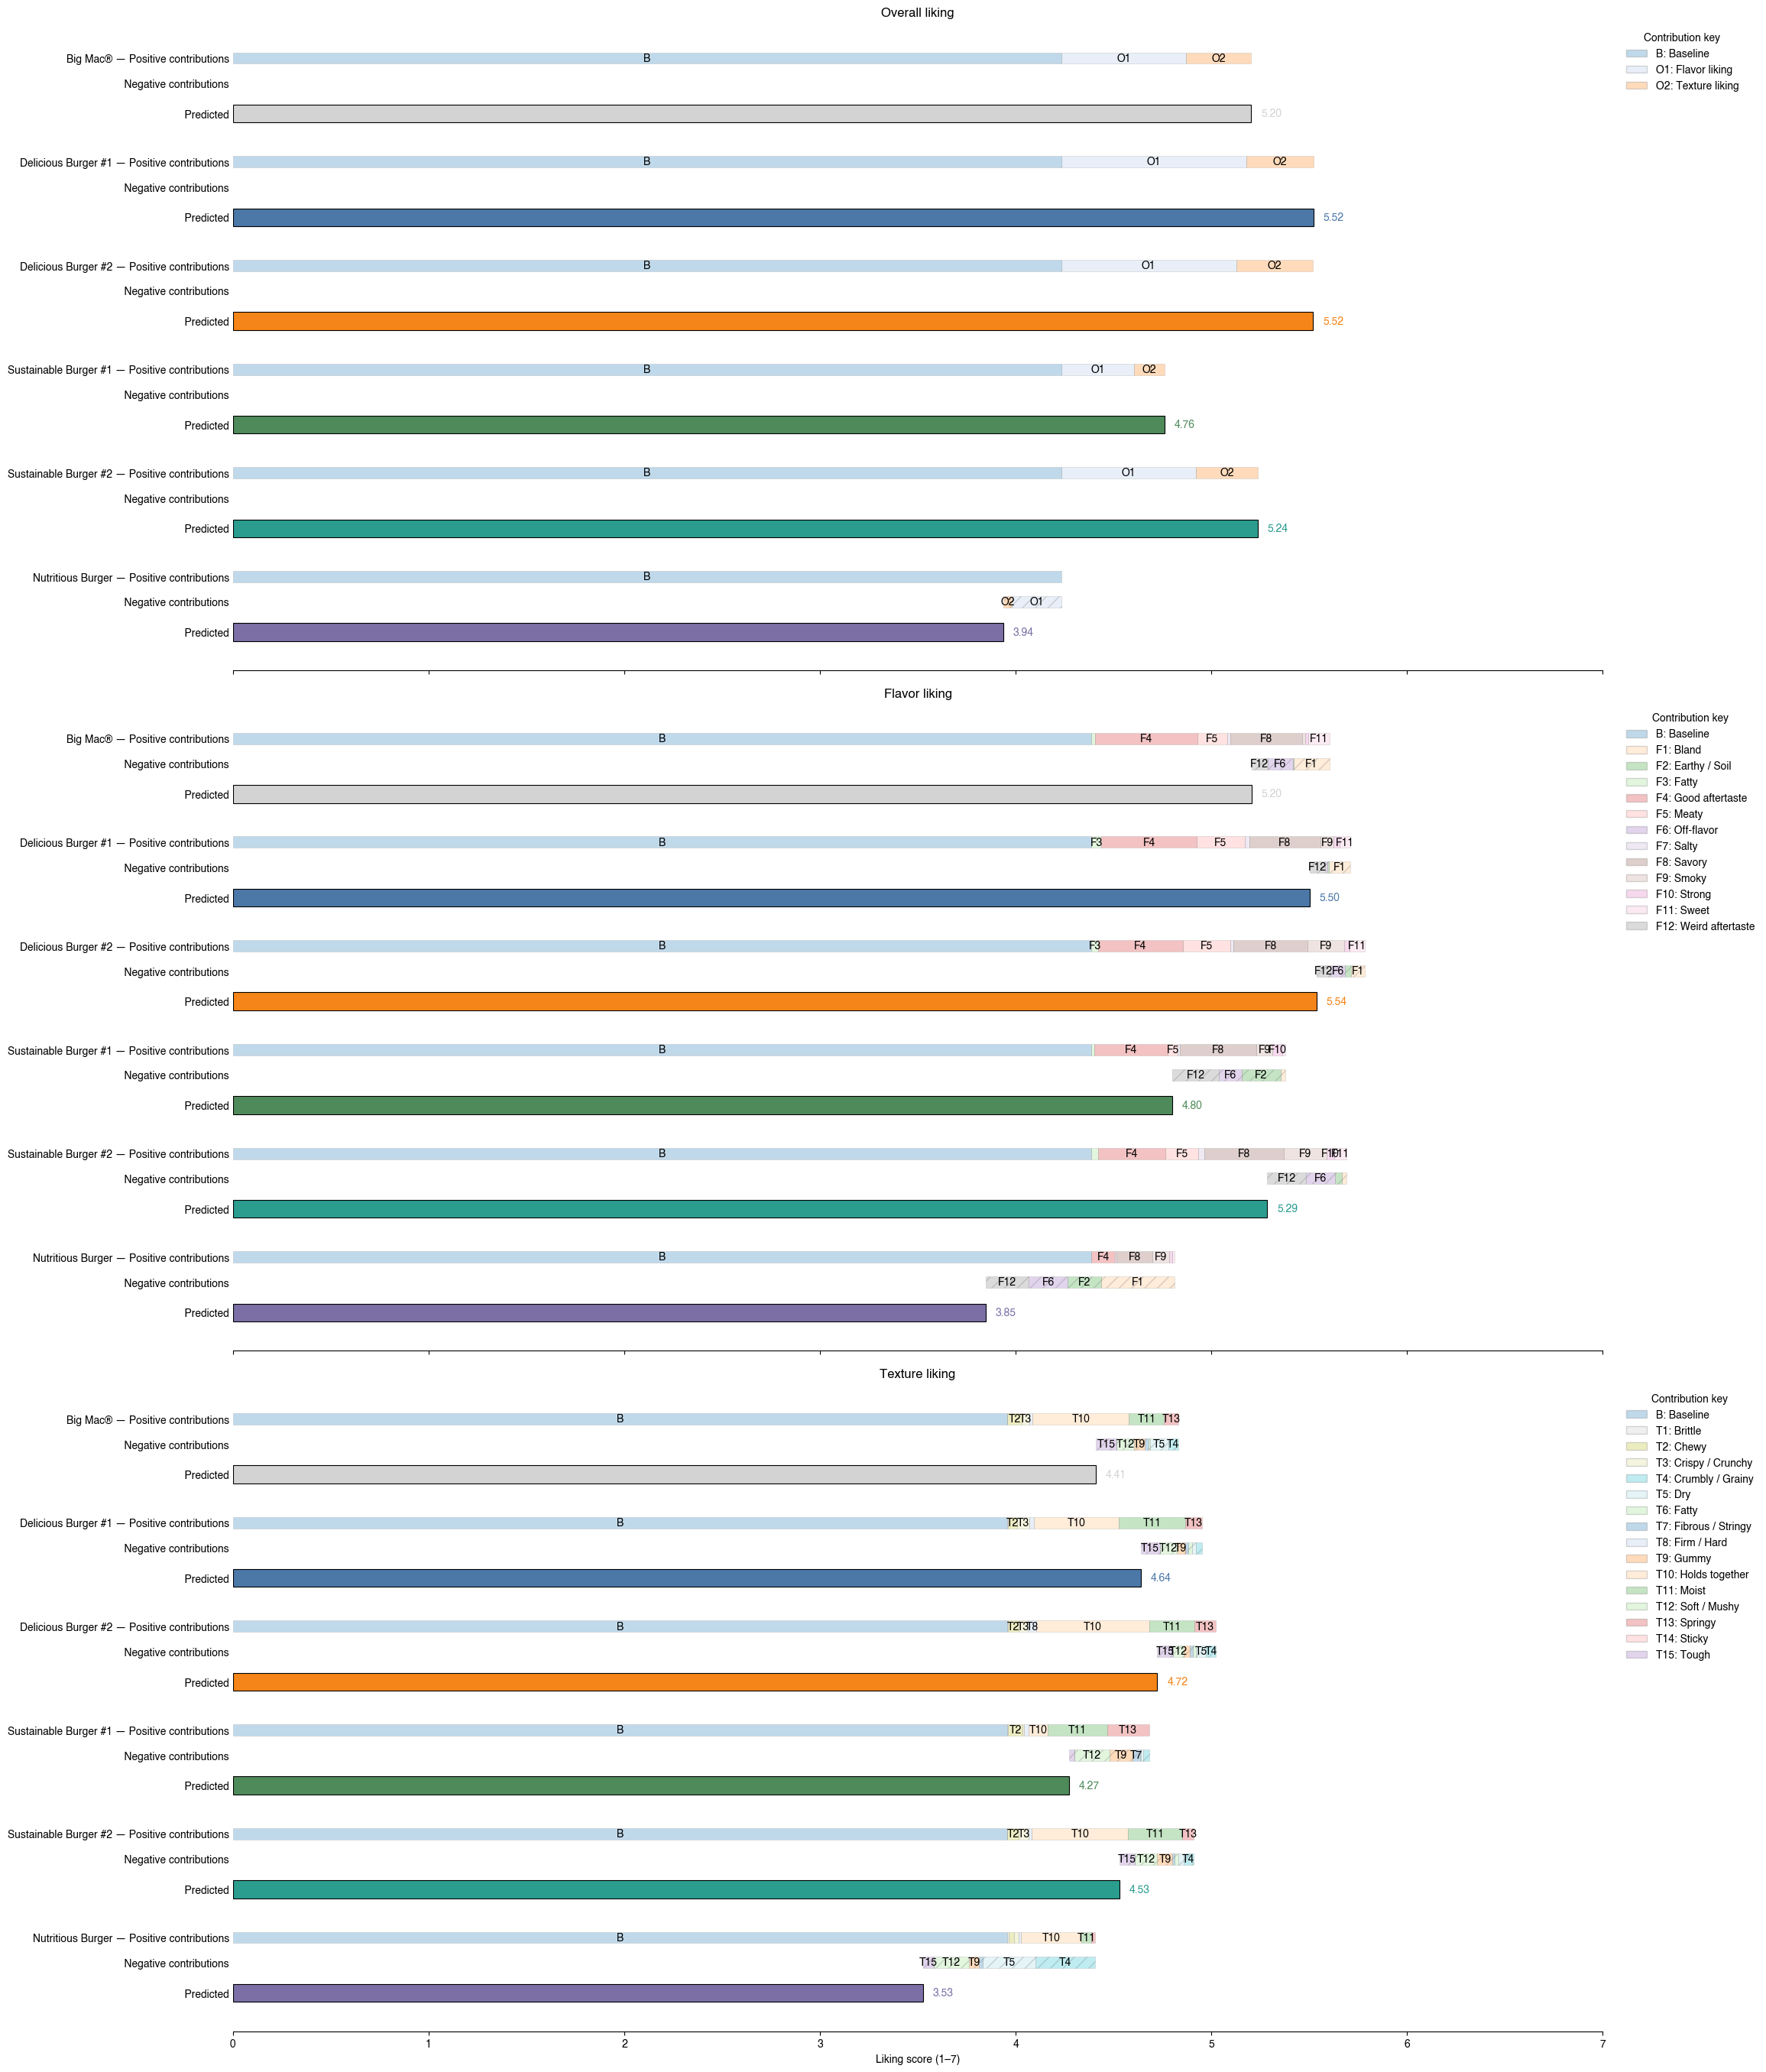

{'Overall liking':                        Baseline  Flavor liking  Texture liking
 product                                                       
 Big Mac                4.232673       0.637156        0.334190
 Delicious Burger #1    4.232673       0.945327        0.343436
 Delicious Burger #2    4.232673       0.894593        0.392642
 Sustainable Burger #1  4.232673       0.373283        0.156294
 Sustainable Burger #2  4.232673       0.688643        0.316400
 Nutritious Burger      4.232673      -0.251001       -0.044474,
 'Flavor liking':                        Baseline     Bland  Earthy / Soil     Fatty  \
 product                                                              
 Big Mac                4.386139 -0.182367      -0.006138  0.020785   
 Delicious Burger #1    4.386139 -0.111970      -0.006595  0.051046   
 Delicious Burger #2    4.386139 -0.069473      -0.030690  0.035631   
 Sustainable Burger #1  4.386139 -0.026052      -0.196414  0.014846   
 Sustainable Burger #2  4.

In [347]:

for outcome_name, prediction_table, contribution_table in validation_decomposition_panels:
    if not np.allclose(
        contribution_table.sum(axis=1), prediction_table['predicted_mean']
    ):
        raise ValueError(f'{outcome_name} contributions do not reconstruct predictions.')

max_positive_endpoint = max(
    table.clip(lower=0).sum(axis=1).max()
    for _, _, table in validation_decomposition_panels
)
decomposition_xmax = max(7.0, np.ceil(max_positive_endpoint * 2) / 2 + 0.5)

fig_validation_decomposition, axes_validation_decomposition = plt.subplots(
    3, 1, figsize=(23, 27), sharex=True, constrained_layout=True,
)

for ax, (outcome_name, prediction_table, contribution_table) in zip(
    axes_validation_decomposition, validation_decomposition_panels
):
    tick_positions, tick_labels = [], []
    code_prefix = {'Overall liking': 'O', 'Flavor liking': 'F', 'Texture liking': 'T'}[
        outcome_name
    ]
    component_codes = {'Baseline': 'B'}
    component_codes.update({
        component: f'{code_prefix}{index}'
        for index, component in enumerate(
            [name for name in contribution_table.columns if name != 'Baseline'],
            start=1,
        )
    })
    for burger_index, burger in enumerate(all_validation_products):
        base_y = burger_index * group_spacing
        burger_color = all_validation_colors[burger]
        predicted = prediction_table.loc[burger, 'predicted_mean']
        pieces = contribution_table.loc[burger]

        positive_cursor = 0.0
        for component, value in pieces.items():
            if value <= 1e-10:
                continue
            ax.barh(base_y + row_offsets[0], value, left=positive_cursor,
                    height=0.32, color=component_colors[component], alpha=0.28,
                    edgecolor='0.45', linewidth=0.45)
            if value >= 0.035:
                ax.text(positive_cursor + value / 2, base_y + row_offsets[0],
                        component_codes[component], ha='center', va='center',
                        clip_on=True)
            positive_cursor += value

        negative_cursor = positive_cursor
        for component, value in pieces.items():
            if value >= -1e-10:
                continue
            segment_left = negative_cursor + value
            ax.barh(base_y + row_offsets[1], -value, left=segment_left,
                    height=0.32, color=component_colors[component], alpha=0.28,
                    edgecolor='0.45', linewidth=0.45, hatch='//')
            if -value >= 0.035:
                ax.text(segment_left - value / 2, base_y + row_offsets[1],
                        component_codes[component], ha='center', va='center',
                        clip_on=True)
            negative_cursor += value

        ax.barh(base_y + row_offsets[2], predicted, height=0.50,
                color=burger_color, edgecolor='black', linewidth=0.8)
        ax.text(predicted + 0.05, base_y + row_offsets[2], f'{predicted:.2f}',
                ha='left', va='center', color=burger_color)

        tick_positions.extend(base_y + np.array(row_offsets))
        display_name = all_validation_display_names[burger]
        tick_labels.extend([
            f'{display_name} — Positive contributions',
            '    Negative contributions', '    Predicted',
        ])

    ax.set_yticks(tick_positions, tick_labels)
    ax.invert_yaxis()
    ax.set_xlim(0, decomposition_xmax)
    ax.set_title(outcome_name)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    component_key = [
        Patch(
            facecolor=component_colors[component], edgecolor='0.45', alpha=0.28,
            label=f'{component_codes[component]}: {component}',
        )
        for component in contribution_table.columns
    ]
    ax.legend(
        handles=component_key, frameon=False, loc='upper left',
        bbox_to_anchor=(1.01, 1), ncols=1, title='Contribution key',
    )

axes_validation_decomposition[-1].set_xlabel('Liking score (1–7)')
plt.show()

validation_prediction_contributions = {
    outcome_name: table
    for outcome_name, _, table in validation_decomposition_panels
}
validation_prediction_contributions

# 6. Processing effects

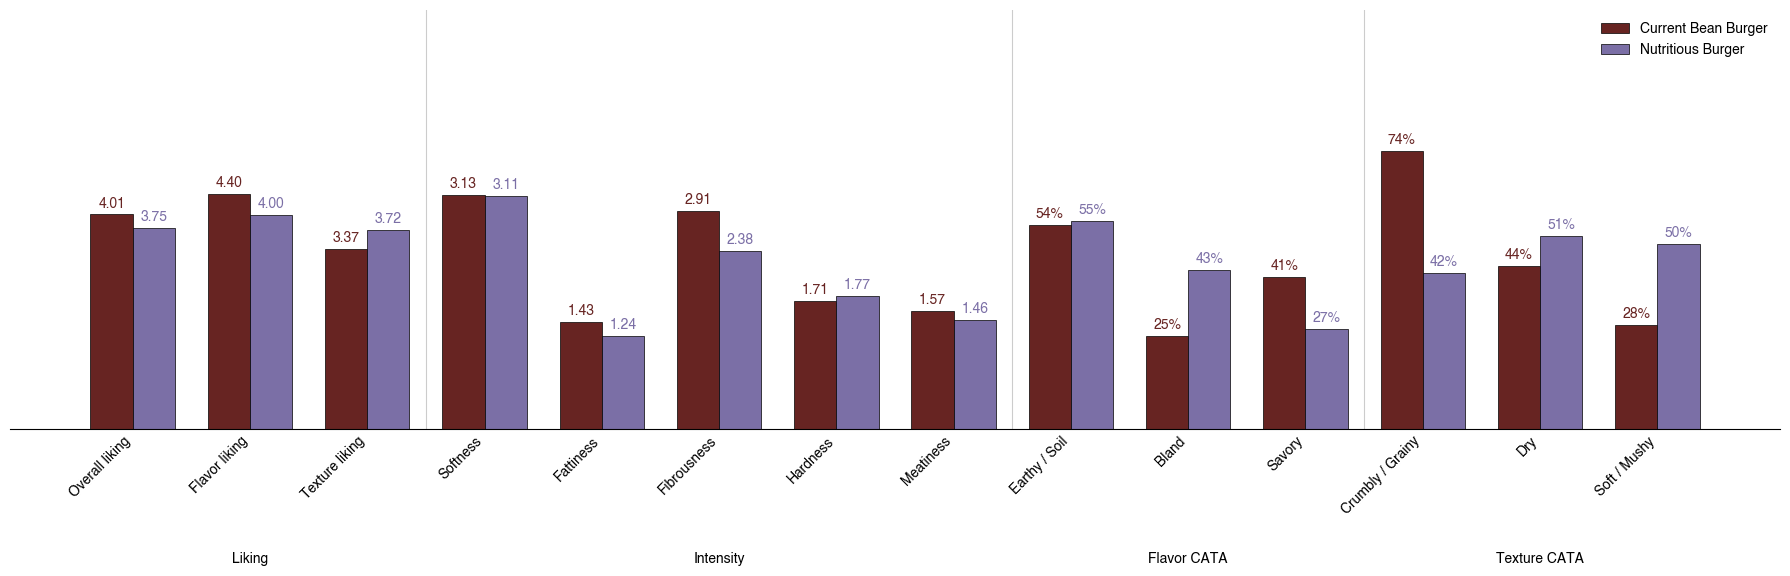

({'Flavor': ['Earthy / Soil', 'Bland', 'Savory'],
  'Texture': ['Crumbly / Grainy', 'Dry', 'Soft / Mushy']},
            group           measure             label            product  \
 0         Liking    Overall Liking    Overall liking               Bean   
 1         Liking    Overall Liking    Overall liking  Nutritious Burger   
 2         Liking            Flavor     Flavor liking               Bean   
 3         Liking            Flavor     Flavor liking  Nutritious Burger   
 4         Liking           Texture    Texture liking               Bean   
 5         Liking           Texture    Texture liking  Nutritious Burger   
 6      Intensity          Softness          Softness               Bean   
 7      Intensity          Softness          Softness  Nutritious Burger   
 8      Intensity         Fattiness         Fattiness               Bean   
 9      Intensity         Fattiness         Fattiness  Nutritious Burger   
 10     Intensity       Fibrousness       Fibrousness  

In [335]:
processing_products = ['Bean', 'Nutritious Burger']
processing_display_names = {
    'Bean': 'Current Bean Burger',
    'Nutritious Burger': 'Nutritious Burger',
}
processing_colors = {
    'Bean': burger_colors['Bean'],
    'Nutritious Burger': validation_colors['Nutritious Burger'],
}

# Combine the rating responses from the two survey waves.
current_bean_ratings = survey_numeric.loc[
    survey_numeric['product'].eq('Bean'),
    ['Respondent', 'product', 'scale', 'modality', 'response_numeric'],
].copy()
nutritious_ratings = survey_previous_long.loc[
    survey_previous_long['product'].eq('Nutritious Burger')
    & survey_previous_long['response_numeric'].notna(),
    ['Respondent', 'product', 'scale', 'modality', 'response_numeric'],
].copy()
nutritious_ratings['response_numeric'] = (
    nutritious_ratings['response_numeric'].astype(int)
)
nutritious_ratings['modality'] = nutritious_ratings['modality'].replace(
    {'Fibrosity': 'Fibrousness'}
)
processing_ratings = pd.concat(
    [current_bean_ratings, nutritious_ratings], ignore_index=True
)
processing_rating_means = (
    processing_ratings.groupby(['product', 'scale', 'modality'])[
        'response_numeric'
    ].mean()
)

# Build binary CATA data, including respondents who selected no attributes.
current_bean_cata = extract_cata_selections(
    survey_long.loc[survey_long['product'].eq('Bean')]
)
nutritious_cata = extract_cata_selections(
    survey_previous_long.loc[
        survey_previous_long['product'].eq('Nutritious Burger')
    ]
)
processing_cata = pd.concat(
    [current_bean_cata, nutritious_cata], ignore_index=True
)
processing_evaluations = pd.concat([
    survey_long.loc[
        survey_long['product'].eq('Bean'), ['Respondent', 'product']
    ],
    survey_previous_long.loc[
        survey_previous_long['product'].eq('Nutritious Burger'),
        ['Respondent', 'product'],
    ],
]).drop_duplicates()
processing_evaluation_index = pd.MultiIndex.from_frame(
    processing_evaluations[['Respondent', 'product']]
)
processing_cata_binary = (
    pd.crosstab(
        [processing_cata['Respondent'], processing_cata['product']],
        [processing_cata['modality'], processing_cata['attribute']],
    )
    .clip(upper=1)
    .reindex(processing_evaluation_index, fill_value=0)
)
processing_cata_prevalence = (
    processing_cata_binary.groupby(level='product').mean() * 100
)

top_processing_cata_attributes = {}
for modality in ['Flavor', 'Texture']:
    modality_prevalence = processing_cata_prevalence[modality]
    top_processing_cata_attributes[modality] = (
        modality_prevalence.mean(axis=0).nlargest(3).index.tolist()
    )

processing_question_specs = [
    ('Liking', 'Overall Liking', 'Overall liking', 7),
    ('Liking', 'Flavor', 'Flavor liking', 7),
    ('Liking', 'Texture', 'Texture liking', 7),
    ('Intensity', 'Softness', 'Softness', 5),
    ('Intensity', 'Fattiness', 'Fattiness', 5),
    ('Intensity', 'Fibrousness', 'Fibrousness', 5),
    ('Intensity', 'Hardness', 'Hardness', 5),
    ('Intensity', 'Meatiness', 'Meatiness', 5),
]
processing_rows = []
for scale, modality, label, scale_maximum in processing_question_specs:
    for product in processing_products:
        raw_value = processing_rating_means.loc[(product, scale, modality)]
        processing_rows.append({
            'group': scale, 'measure': modality, 'label': label,
            'product': product, 'raw_value': raw_value,
            'plot_percentage': raw_value / scale_maximum * 100,
            'value_label': f'{raw_value:.2f}',
        })

for modality in ['Flavor', 'Texture']:
    for attribute in top_processing_cata_attributes[modality]:
        for product in processing_products:
            prevalence = processing_cata_prevalence.loc[
                product, (modality, attribute)
            ]
            processing_rows.append({
                'group': f'{modality} CATA',
                'measure': attribute,
                'label': attribute,
                'product': product,
                'raw_value': prevalence,
                'plot_percentage': prevalence,
                'value_label': f'{prevalence:.0f}%',
            })
processing_comparison_table = pd.DataFrame(processing_rows)

processing_measure_order = (
    [spec[1] for spec in processing_question_specs]
    + top_processing_cata_attributes['Flavor']
    + top_processing_cata_attributes['Texture']
)
processing_labels = (
    [spec[2] for spec in processing_question_specs]
    + top_processing_cata_attributes['Flavor']
    + top_processing_cata_attributes['Texture']
)
processing_positions = np.arange(len(processing_measure_order))
processing_bar_width = 0.36

fig_processing, ax_processing = plt.subplots(figsize=(18, 6))
for product_index, product in enumerate(processing_products):
    product_values = (
        processing_comparison_table.loc[
            processing_comparison_table['product'].eq(product)
        ]
        .set_index('measure')
        .reindex(processing_measure_order)
    )
    x_offset = (product_index - 0.5) * processing_bar_width
    bars = ax_processing.bar(
        processing_positions + x_offset, product_values['plot_percentage'],
        width=processing_bar_width, color=processing_colors[product],
        edgecolor='black', linewidth=0.5,
        label=processing_display_names[product],
    )
    for bar, value_label in zip(bars, product_values['value_label']):
        ax_processing.annotate(
            value_label,
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', color=processing_colors[product],
        )

for boundary in [2.5, 7.5, 10.5]:
    ax_processing.axvline(boundary, color='0.8', linewidth=0.8)

ax_processing.set_xticks(processing_positions, processing_labels, rotation=45, ha='right')
ax_processing.set_ylim(0, 112)
ax_processing.set_yticks([])
ax_processing.tick_params(axis='x', length=0)
ax_processing.spines[['top', 'right', 'left']].set_visible(False)
ax_processing.legend(frameon=False, loc='upper right')
ax_processing.text(1, -0.32, 'Liking', transform=ax_processing.get_xaxis_transform(), ha='center')
ax_processing.text(5, -0.32, 'Intensity', transform=ax_processing.get_xaxis_transform(), ha='center')
ax_processing.text(9, -0.32, 'Flavor CATA', transform=ax_processing.get_xaxis_transform(), ha='center')
ax_processing.text(12, -0.32, 'Texture CATA', transform=ax_processing.get_xaxis_transform(), ha='center')
fig_processing.tight_layout()
plt.show()

top_processing_cata_attributes, processing_comparison_table

Index of selected recipe:  773152
Novelty score:  4
Index of selected recipe:  378301
Novelty score:  3
Index of selected recipe:  128796
Novelty score:  4
Index of selected recipe:  934442
Novelty score:  4
Index of selected recipe:  668247
Novelty score:  3
Index of selected recipe:  614202
Novelty score:  2
Index of selected recipe:  497118
Novelty score:  3
Index of selected recipe:  23661
Novelty score:  4


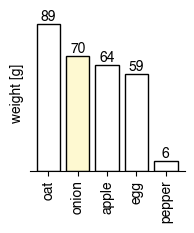

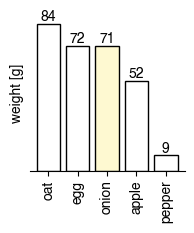

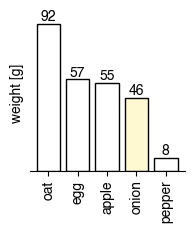

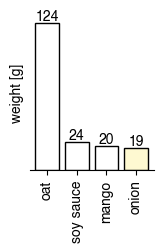

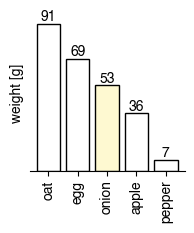

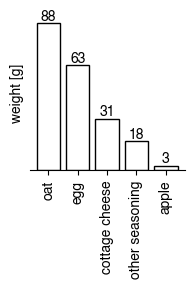

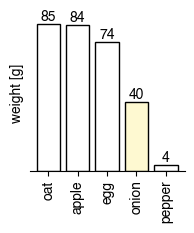

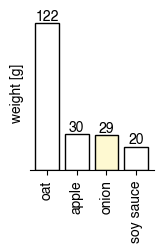

In [90]:
# order = np.argsort(oat_fruit_repeat_counts)[::-1]
# for idx_max in order:
#     recipe = find_recipe_in_batch(oat_fruit_recipes[idx_max])
#     recipe[recipe<1] = 0
#     print("Index of selected recipe: ", int(oat_fruit_recipes[idx_max]))
#     sds = batched_sds_jit(recipe, gt_recipes)
#     print("Novelty score: ", np.min(sds))
#     plot_recipe(recipe)

(<Figure size 320x200 with 1 Axes>, <Axes: ylabel='weight [g]'>)

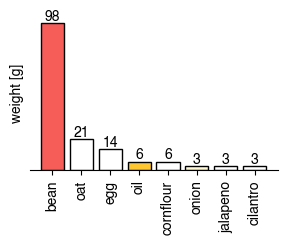

In [55]:
# bean_burger_init = {'bean': 71,
#                     'cilantro': 2,
#                     'cornflour': 4,
#                     'cumin': 0.2,
#                     'egg': 10,
#                     'jalapeno': 2,
#                     'oat': 15,
#                     'oil': 4,
#                     'onion': 2,
#                     'oregano': 0.05,
#                     'pepper': 0.2}

# recipe = np.zeros_like(gt_recipes[0])
# for name, qnty in bean_burger_init.items():
#     idx_ingr = np.where(ingr_names == name)[0][0]
#     recipe[idx_ingr] = qnty

# #Make it 350 calories
# calories = 0
# for i in range(len(recipe)):
#     name = ingr_names[i]
#     qnty = recipe[i]
#     calories_per_gram = calorie_database[name]
#     calories += calories_per_gram*qnty

# recipe = recipe/calories*350
# recipe[recipe<1] = 0
# plot_recipe(recipe)